# Forecasting Equity Returns with Linear Time Series Models
## An ARMA Framework Applied to S&P 500 Daily Log Returns
### Thesis Introduction — Quantitative Finance

---

> **Abstract.** This notebook develops a complete empirical investigation of linear
> autoregressive moving-average (ARMA) models applied to daily log returns of the
> S&P 500 index (proxied by SPY). We treat the price series as a stochastic
> observable generated by a complex adaptive system, apply formal stationarity
> testing before any modelling, select model orders via information-theoretic
> criteria, diagnose residuals against theoretical predictions, and validate
> predictive performance through a rigorous walk-forward protocol. The exercise
> is designed not to produce trading alpha — it is designed to establish the
> empirical null against which all subsequent nonlinear models are benchmarked.
> Understanding *why* ARMA fails is as scientifically valuable as understanding
> *when* it succeeds.

---

## Table of Contents

1. [Theoretical Foundation](#1-theoretical-foundation)
2. [The Stochastic Process Framework](#2-the-stochastic-process-framework)
3. [The ARMA Model — Complete Specification](#3-the-arma-model--complete-specification)
4. [Window Selection — The Bias-Variance-Nonstationarity Tradeoff](#4-window-selection--the-bias-variance-nonstationarity-tradeoff)
5. [Configuration and Dependencies](#5-configuration-and-dependencies)
6. [Data Acquisition and Preparation](#6-data-acquisition-and-preparation)
7. [Stationarity Testing](#7-stationarity-testing)
8. [Distributional Diagnostics](#8-distributional-diagnostics)
9. [ACF and PACF Analysis](#9-acf-and-pacf-analysis)
10. [Order Selection via Information Criteria](#10-order-selection-via-information-criteria)
11. [Window Sensitivity Analysis](#11-window-sensitivity-analysis)
12. [Model Fitting and Coefficient Interpretation](#12-model-fitting-and-coefficient-interpretation)
13. [Residual Diagnostics](#13-residual-diagnostics)
14. [Impulse Response Function](#14-impulse-response-function)
15. [Walk-Forward Evaluation](#15-walk-forward-evaluation)
16. [Performance Scorecard](#16-performance-scorecard)
17. [Conclusions and Motivation for Nonlinear Extensions](#17-conclusions-and-motivation-for-nonlinear-extensions)

---

## 1. Theoretical Foundation

### 1.1 The Epistemological Stance

Financial markets are **complex adaptive systems**: the participants who observe and
act on price patterns are the same agents who generate those patterns. This creates
a fundamental reflexivity absent in physical systems — any stable, exploitable
statistical regularity attracts capital that arbitrages it away, reducing its
persistence. The implication for modelling is severe:

> We are not predicting a passive stochastic process with fixed parameters.
> We are extracting signal from a system that partially adapts to our predictions.

The appropriate scientific posture is therefore one of **disciplined scepticism**.
We begin with the weakest, most parsimonious model class — linear time series models
— and document their failure precisely. This failure is not a dead end; it is a map
of where nonlinear structure must be sought.

The formal null hypothesis we test throughout this notebook is the **Efficient
Market Hypothesis (EMH)** in its weak form:

$$\mathcal{H}_0: \quad \mathbb{E}[r_{t+h} \mid \mathcal{F}_t] = \mu \qquad \forall h \geq 1$$

where $r_{t+h}$ is the log return at horizon $h$, $\mathcal{F}_t$ is the
filtration (information set) at time $t$, and $\mu$ is an unconditional constant.
Under $\mathcal{H}_0$, past returns carry no information about future returns beyond
their unconditional mean — the process is a **martingale difference sequence** with
respect to $\mathcal{F}_t$.

The ARMA model provides the most general linear test of $\mathcal{H}_0$.

---

## 2. The Stochastic Process Framework

### 2.1 Stationarity — The Central Requirement

Every ARMA-class model requires the modelled series to be **covariance stationary**.

**Definition (Weak Stationarity).** A stochastic process $\{X_t\}_{t \in \mathbb{Z}}$
is weakly (or covariance) stationary if:

$$\mathbb{E}[X_t] = \mu \qquad \forall t \qquad \text{(constant mean)}$$

$$\text{Cov}(X_t, X_{t-k}) = \gamma(k) \qquad \forall t,\, \forall k \qquad \text{(autocovariance depends only on lag } k \text{)}$$

$$\mathbb{E}[X_t^2] < \infty \qquad \forall t \qquad \text{(finite variance)}$$

The **autocovariance function** $\gamma(k)$ and the normalised
**autocorrelation function (ACF)** are:

$$\gamma(k) = \text{Cov}(X_t, X_{t-k}), \qquad
\rho(k) = \frac{\gamma(k)}{\gamma(0)} \in [-1, 1]$$

When $\rho(k) = 0$ for all $k \geq 1$, the process is called **white noise** —
its past carries zero information about its future. This is the EMH in probabilistic
language.

### 2.2 The Integrated Process — Why Prices Are Not Stationary

Equity log-prices $\log P_t$ are **not** weakly stationary. Their mean grows over
time (positive expected return) and their variance grows linearly with the time
horizon:

$$\text{Var}(\log P_t) = t \cdot \sigma^2 \longrightarrow \infty \quad \text{as } t \to \infty$$

This is the signature of an **integrated process of order 1**, denoted $\log P_t \sim I(1)$.
The first difference of an $I(1)$ process is stationary:

$$r_t = \Delta \log P_t = \log P_t - \log P_{t-1} \sim I(0)$$

This is why we model **log returns** $r_t$, not prices $P_t$. The log return is
approximately equal to the percentage return for small values:

$$r_t = \log\!\left(\frac{P_t}{P_{t-1}}\right) \approx \frac{P_t - P_{t-1}}{P_{t-1}}$$

and it has the convenient additive property over multi-period horizons:

$$r_{t:t+h} = \sum_{k=1}^{h} r_{t+k} = \log\!\left(\frac{P_{t+h}}{P_t}\right)$$

### 2.3 The Wold Decomposition Theorem

The Wold theorem provides the theoretical justification for the entire ARMA
model class:

**Theorem (Wold, 1938).** Every covariance-stationary process $\{X_t\}$ with
zero mean admits the decomposition:

$$X_t = \sum_{j=0}^{\infty} \psi_j \epsilon_{t-j} + \eta_t$$

where $\{\epsilon_t\}$ is white noise with variance $\sigma^2$, $\psi_0 = 1$,
$\sum_{j=0}^{\infty} \psi_j^2 < \infty$, and $\eta_t$ is a deterministic component
perfectly predictable from its own past.

**Why this matters.** The Wold theorem guarantees that *every* covariance-stationary
process has an infinite-order MA representation, $\text{MA}(\infty)$. The ARMA model
is a **parsimonious finite-parameter approximation** to this infinite representation.
This is not an assumption — it is a theorem. The only assumption is stationarity
itself.

---

## 3. The ARMA Model — Complete Specification

### 3.1 Model Definition

The **$ARMA(p, q)$** model for the stationary series $r_t$ is:

$$\boxed{r_t = c + \sum_{i=1}^{p} \phi_i\, r_{t-i} + \epsilon_t + \sum_{j=1}^{q} \theta_j\, \epsilon_{t-j}}$$

where:

| Symbol | Name | Role |
|:------:|:-----|:-----|
| $c$ | Intercept | Unconditional mean $\mu = c / (1 - \sum_i \phi_i)$ |
| $\phi_i$ | AR coefficients | Weight on past return at lag $i$ |
| $\theta_j$ | MA coefficients | Weight on past shock at lag $j$ |
| $\epsilon_t$ | Innovation | $\overset{iid}{\sim}(0, \sigma^2)$, unpredictable shock |
| $p$ | AR order | Number of autoregressive lags |
| $q$ | MA order | Number of moving-average lags |

Using the **backshift operator** $B^k r_t \equiv r_{t-k}$, define the lag polynomials:

$$\Phi(B) = 1 - \phi_1 B - \phi_2 B^2 - \cdots - \phi_p B^p$$

$$\Theta(B) = 1 + \theta_1 B + \theta_2 B^2 + \cdots + \theta_q B^q$$

The model compactly becomes:

$$\Phi(B)\, r_t = c + \Theta(B)\, \epsilon_t$$

### 3.2 The AR Component — Autoregressive Memory

The term $\sum_{i=1}^p \phi_i r_{t-i}$ says the current return is a weighted
linear combination of the last $p$ returns. Each coefficient $\phi_i$ measures
the **direct linear dependence** of $r_t$ on $r_{t-i}$ after controlling for
all intermediate lags. The sign of $\phi_i$ determines the nature of the dependence:

$$\phi_i > 0 \implies \text{momentum — positive returns predict positive returns}$$

$$\phi_i < 0 \implies \text{mean reversion — positive returns predict negative returns}$$

**Stationarity condition.** The $AR(p)$ component is stationary if and only if
all roots of the characteristic polynomial $\Phi(z) = 0$ lie strictly outside the
unit circle in the complex plane:

$$|z_k| > 1 \quad \forall k = 1, \ldots, p$$

For the $AR(1)$ case, this reduces to $|\phi_1| < 1$. When $\phi_1 = 1$, the process
is a **random walk** — the most important special case for equity prices:

$$r_t = r_{t-1} + \epsilon_t \implies P_t = P_0 + \sum_{k=1}^t \epsilon_k, \quad \text{Var}(P_t) = t\sigma^2$$

The random walk is the mathematical model of an efficient market. Its price variance
grows without bound, consistent with the observed non-stationarity of equity prices.

### 3.3 The MA Component — Shock Propagation

The term $\sum_{j=1}^q \theta_j \epsilon_{t-j}$ expresses how past unexpected
shocks (news events, liquidity shocks, order flow imbalances) propagate into current
returns. The innovation $\epsilon_{t-j}$ is the component of the return at time
$t-j$ that was *not* predicted by the model — a pure surprise.

The coefficient $\theta_j$ measures how much that $j$-period-old surprise still
affects today's return:

$$\theta_j > 0 \implies \text{the shock's effect persists (under-reaction to news)}$$

$$\theta_j < 0 \implies \text{the shock reverses (over-reaction and correction)}$$

**Invertibility condition.** The $MA(q)$ process is invertible — it has an
$AR(\infty)$ representation — if all roots of $\Theta(z) = 0$ lie strictly outside
the unit circle. Invertibility ensures a unique parameterisation.

**The $MA(1)$ bid-ask bounce.** At daily frequency, a well-documented phenomenon
is the bid-ask bounce: if a trade occurs at the ask, the price is pushed up by
$\frac{1}{2}$ the spread; the next trade is equally likely to occur at the bid,
pushing the price down. This creates a **negative $MA(1)$ coefficient**:

$$\hat{\theta}_1 < 0 \quad \text{(bid-ask bounce signature)}$$

For liquid large-cap equities (e.g., SPY), this effect is negligible — spreads
are approximately $1$ basis point — so we do not expect a strongly significant
$\theta_1$.

### 3.4 The One-Step-Ahead Forecast

The conditional expectation given the information set $\mathcal{F}_{t}$ is:

$$\hat{r}_{t+1} = \mathbb{E}[r_{t+1} \mid \mathcal{F}_t] = \hat{c} + \sum_{i=1}^{p} \hat{\phi}_i\, r_{t+1-i} + \sum_{j=1}^{q} \hat{\theta}_j\, \hat{\epsilon}_{t+1-j}$$

The AR part uses *observable* past returns $r_{t}, r_{t-1}, \ldots$. The MA part
uses *estimated* past innovations $\hat{\epsilon}_{t-j} = r_{t-j} - \hat{r}_{t-j}$,
computed recursively from the model's own prediction errors. This recursive
dependency is why MA models cannot be estimated by ordinary least squares — they
require maximum likelihood.

### 3.5 The $h$-Step-Ahead Forecast

For horizons $h > 1$, we use the **direct forecasting** approach: a separate ARMA
model is estimated for each target horizon $h$, where the dependent variable is
the $h$-period cumulative return $r_{t:t+h} = \sum_{k=1}^h r_{t+k}$:

$$r_{t:t+h} = c^{(h)} + \sum_{i=1}^{p^{(h)}} \phi_i^{(h)}\, r_{t+1-i} + \sum_{j=1}^{q^{(h)}} \theta_j^{(h)}\, \epsilon_{t+1-j}^{(h)} + \epsilon_{t+h}^{(h)}$$

Direct forecasting is preferred over **iterated forecasting** (applying the 1-step
model recursively) when the model is misspecified — which is essentially guaranteed
in financial applications. Under misspecification, direct forecasting is more robust
because each horizon optimises its own parameters, whereas iterated forecasting
propagates the misspecification error multiplicatively.

### 3.6 Parameter Estimation — Maximum Likelihood

The parameter vector $\boldsymbol{\vartheta} = (c, \phi_1, \ldots, \phi_p, \theta_1, \ldots, \theta_q, \sigma^2)$
is estimated by maximising the conditional log-likelihood:

$$\hat{\boldsymbol{\vartheta}} = \underset{\boldsymbol{\vartheta}}{\arg\max}\; \ell(\boldsymbol{\vartheta})$$

$$\ell(\boldsymbol{\vartheta}) = -\frac{T}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{t=1}^{T} \epsilon_t^2(\boldsymbol{\vartheta})$$

where the innovations are computed recursively:

$$\epsilon_t(\boldsymbol{\vartheta}) = r_t - c - \sum_{i=1}^{p} \phi_i\, r_{t-i} - \sum_{j=1}^{q} \theta_j\, \epsilon_{t-j}(\boldsymbol{\vartheta})$$

The score equations $\partial \ell / \partial \boldsymbol{\vartheta} = 0$ have no
closed-form solution — numerical optimisation (L-BFGS-B) is required. Initialisation
uses the Yule-Walker equations for the AR part and method-of-moments for the MA part.

The conditional (Fisher) information matrix provides the asymptotic covariance of
the MLE:

$$\sqrt{T}\,(\hat{\boldsymbol{\vartheta}} - \boldsymbol{\vartheta}_0) \overset{d}{\longrightarrow} \mathcal{N}\!\left(0,\, \mathcal{I}^{-1}(\boldsymbol{\vartheta}_0)\right)$$

where $\mathcal{I}(\boldsymbol{\vartheta}) = -\mathbb{E}[\partial^2 \ell / \partial \boldsymbol{\vartheta}\, \partial \boldsymbol{\vartheta}^\top]$
is the Fisher information matrix. Standard errors reported in the coefficient table
are $\text{se}(\hat{\phi}_i) = \sqrt{\mathcal{I}^{-1}_{ii} / T}$.

---

## 4. Window Selection — The Bias-Variance-Nonstationarity Tradeoff

### 4.1 Three Distinct Windows

Every rolling ARMA implementation involves three separate window decisions:

$$\underbrace{W_{\text{train}}}_{\text{how much history to use}} \qquad
\underbrace{(p, q)}_{\text{model memory}} \qquad
\underbrace{W_{\text{retrain}}}_{\text{how often to re-estimate}}$$

These are conceptually distinct and must not be conflated.

### 4.2 The Estimation Window $W_{\text{train}}$

For a rolling window of length $W$, the bias-variance decomposition of the
coefficient estimator is:

$$\text{MSE}(\hat{\phi}_W) = \underbrace{\left(\mathbb{E}[\hat{\phi}_W] - \phi_t\right)^2}_{\substack{\text{regime bias} \\ \text{increases with } W}} + \underbrace{\frac{\text{Var}(\phi)}{W}}_{\substack{\text{estimation variance} \\ \text{decreases with } W}}$$

A long window $W$ reduces estimation variance but increases bias if the process
has experienced a **regime change** within the window — the estimated coefficient
is a mixture of pre- and post-break values. A short window $W$ reduces regime
bias but inflates estimation variance, producing unstable coefficients.

The optimal $W^*$ minimises total MSE. Since the rate of regime change is unknown
and time-varying, we **empirically select** $W^*$ via the window sensitivity
analysis in Section 11: we try $W \in \{126, 252, 504, 756\}$ days (6 months,
1 year, 2 years, 3 years) and adopt the window that maximises out-of-sample
predictive accuracy as measured by the Information Coefficient.

**Default choice: $W = 504$ days (2 years).** This provides sufficient observations
for stable ARMA estimation (approximately $504 / (p + q + 2)$ degrees of freedom
per parameter) while limiting regime contamination. The US equity market experiences
significant structural breaks roughly every 3–7 years (dot-com bust 2000, GFC 2008,
COVID 2020, rate-shock 2022), so a 2-year window rarely spans more than one major
regime transition.

### 4.3 The Model Memory $(p, q)$

The orders $p$ and $q$ determine how many past observations the model uses.
They are selected by minimising the **Bayesian Information Criterion (BIC)**:

$$\text{BIC}(p,q) = -2\,\hat{\ell}(p,q) + (p+q+2)\ln T$$

BIC is preferred over AIC because it is **consistent**: it selects the true model
order with probability approaching 1 as $T \to \infty$. The AIC tends to over-select
in the presence of near-white-noise series — it finds spurious structure that BIC
correctly penalises. The corrected AIC for small samples is:

$$\text{AICc}(p,q) = \text{AIC}(p,q) + \frac{2k(k+1)}{T - k - 1}, \quad k = p + q + 2$$

AICc reduces to AIC as $T \to \infty$ and is preferred when $T/k < 40$.

**Practical upper bounds: $p_{\max} = q_{\max} = 5$.** No documented financial
mechanism generates AR or MA structure beyond 5–7 lags in daily equity log returns.
Searching beyond this range fits noise and inflates the risk of spurious parameter
detection.

### 4.4 The Re-Estimation Frequency $W_{\text{retrain}}$

We re-estimate the ARMA model every $W_{\text{retrain}} = 21$ days (one calendar
month). This choice balances:

- **Adaptiveness:** Monthly re-estimation allows the model to respond to regime
  changes within approximately one month.
- **Computational cost:** Re-estimating every day multiplies runtime by 21×
  with negligible improvement in predictive accuracy for monthly-rebalanced signals.
- **Statistical stability:** Coefficients estimated on 504-day windows change
  slowly — daily re-estimation produces nearly identical results to monthly.


In [15]:
import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns

def load_data_from_csv(csv_file: str) -> pd.DataFrame:
    # yfinance CSV export uses a 2-row header for MultiIndex columns and a standalone index-name row.
    data = pd.read_csv(csv_file, header=[0, 1], skiprows=[2], index_col=0)

    data.index = pd.to_datetime(data.index)
    data.index.name = "Date"

    return data


# script_dir = Path(__file__).resolve().parent
output_file = Path(r"G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_data_only_1993-01-29_to_2026-01-02.csv")  # script_dir / "sp500_data_only_1993-01-29_to_2026-01-02.csv"

if not output_file.exists():
    raise FileNotFoundError(
        f"CSV not found: {output_file}. Place the file next to this script or provide an absolute path."
    )

data_from_csv = load_data_from_csv(output_file)

def get_weights_ffd(d, thres=1e-4):
    """Calculate FFD weights."""
    w = [1.]
    k = 1
    while abs(w[-1]) >= thres:
        w_new = -w[-1] / k * (d - k + 1)
        w.append(w_new)
        k += 1
    return np.array(w[::-1]).reshape(-1, 1)

def frac_diff_ffd(series, d, thres=1e-4):
    w = get_weights_ffd(d, thres)
    width = len(w) - 1
    df = {}
    for name in series.columns:
        seriesF = series[[name]].ffill().dropna()  # Fix Bug 2
        df_ = pd.Series(dtype=float)
        for iloc1 in range(width, seriesF.shape[0]):
            loc0 = seriesF.index[iloc1 - width]
            loc1 = seriesF.index[iloc1]
            slice_ = seriesF.loc[loc0:loc1]
            if len(slice_) != len(w):             # Fix Bug 4
                continue
            if not np.isfinite(slice_[name]).all(): # Fix Bug 3
                continue
            df_[loc1] = np.dot(w.T, slice_)[0, 0]
        df[name] = df_.copy(deep=True)
    return pd.concat(df, axis=1)

# 1. Fetch Data
log_prices = np.log(data_from_csv["Adj Close"][["SPY"]])

diff_log_prices = frac_diff_ffd(log_prices[["SPY"]], d=0.6)

In [16]:

# ── standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")
import itertools
from pathlib import Path

# ── third-party ───────────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import matplotlib.ticker    as mticker
from   scipy  import stats

import yfinance as yf

from statsmodels.tsa.stattools       import adfuller, kpss
from statsmodels.tsa.arima.model     import ARIMA
from statsmodels.stats.diagnostic    import acorr_ljungbox
from statsmodels.graphics.tsaplots   import plot_acf, plot_pacf

# Stationarity Testing: ADF and KPSS

Before applying any time series model, we must formally verify that the series is **stationary** — that its statistical properties do not change over time. Fitting an ARMA model to a non-stationary series produces spurious coefficients that are statistical artefacts rather than genuine structure.

We use two complementary tests because each has a distinct null hypothesis and different weaknesses. Using both together resolves the ambiguity that either test alone leaves open.

---

## 1. The Augmented Dickey-Fuller Test (ADF)

### What It Tests

The ADF tests the null hypothesis that the series **has a unit root** — that is, it is non-stationary:

$$H_0: \text{unit root present} \quad (\text{non-stationary})$$
$$H_1: \text{no unit root} \quad (\text{stationary})$$

### The Test Regression

The ADF fits the following auxiliary regression:

$$\Delta X_t = \alpha + \beta t + \gamma X_{t-1} + \sum_{j=1}^{k} \delta_j \Delta X_{t-j} + u_t$$

where:

| Term | Role |
|:-----|:-----|
| $\alpha$ | Intercept (constant) |
| $\beta t$ | Deterministic trend (optional) |
| $\gamma X_{t-1}$ | The unit root term — this is what we test |
| $\sum \delta_j \Delta X_{t-j}$ | Augmentation lags — absorb serial correlation in $u_t$ |
| $k$ | Number of augmentation lags, chosen by AIC |

The test statistic is:

$$\tau = \frac{\hat{\gamma}}{\text{se}(\hat{\gamma})}$$

Under $H_0: \gamma = 0$ (unit root), $\tau$ does **not** follow a standard $t$-distribution. It follows the **Dickey-Fuller distribution**, which has heavier left tails. The critical values at the 5% level (with constant and trend) are approximately $-3.41$ — much more negative than the standard $t$-critical value of $-1.96$.

### Decision Rule

$$\tau < \tau_{\text{critical}} \implies \text{reject } H_0 \implies \text{series is stationary}$$
$$\tau \geq \tau_{\text{critical}} \implies \text{fail to reject } H_0 \implies \text{series has a unit root}$$

A large $p$-value ($> 0.05$) means we **cannot rule out** a unit root. For log-prices, we expect to fail to reject. For log-returns, we expect to reject decisively.

### Key Weakness

The ADF has **low power against near-unit-root alternatives**. A series with $\phi_1 = 0.97$ is stationary — but the ADF frequently fails to reject the unit root null, incorrectly treating it as non-stationary. This is why the KPSS test is used alongside it.

---

## 2. The KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin)

### What It Tests

The KPSS **reverses the null**. It tests the null hypothesis that the series **is stationary**:

$$H_0: \text{series is stationary}$$
$$H_1: \text{unit root present} \quad (\text{non-stationary})$$

### The Test Statistic

The KPSS decomposes $X_t$ into a deterministic trend, a random walk component, and stationary noise:

$$X_t = \xi t + r_t + \varepsilon_t, \qquad r_t = r_{t-1} + u_t, \quad u_t \sim (0, \sigma_u^2)$$

Under $H_0$: $\sigma_u^2 = 0$ — the random walk component has zero variance, so $X_t$ is trend-stationary. The test statistic is:

$$\text{KPSS} = \frac{1}{T^2 \hat{\lambda}^2} \sum_{t=1}^{T} S_t^2$$

where $S_t = \sum_{j=1}^{t} \hat{e}_j$ is the partial sum of OLS residuals from the trend regression, and $\hat{\lambda}^2$ is a long-run variance estimate (Newey-West). Large values of KPSS indicate that the partial sums grow substantially — evidence of a unit root.

### Decision Rule

$$\text{KPSS} > \text{critical value} \implies \text{reject } H_0 \implies \text{series is non-stationary}$$
$$\text{KPSS} \leq \text{critical value} \implies \text{fail to reject } H_0 \implies \text{series is stationary}$$

A large $p$-value ($> 0.05$) means we **cannot reject** stationarity.

### Key Weakness

The KPSS can reject stationarity in the presence of **structural breaks** even when the series is stationary within each regime. A series that is stationary but shifts its mean in 2008 and again in 2020 may spuriously appear non-stationary to the KPSS.

---

## 3. Joint Interpretation

The two tests have complementary nulls, which means their results can be combined into a definitive joint conclusion:

| ADF result | KPSS result | Joint conclusion |
|:----------:|:-----------:|:----------------:|
| Fail to reject $H_0$ ($p > 0.05$) | Reject $H_0$ ($p < 0.05$) | **Clear $I(1)$ — unit root confirmed** |
| Reject $H_0$ ($p < 0.05$) | Fail to reject $H_0$ ($p > 0.05$) | **Clear $I(0)$ — stationary** |
| Fail to reject $H_0$ | Fail to reject $H_0$ | Ambiguous — insufficient sample size |
| Reject $H_0$ | Reject $H_0$ | Possible structural break or nonlinearity |

### Expected Results for S&P 500 Data

| Series | ADF $p$-value | KPSS $p$-value | Conclusion |
|:-------|:-------------:|:--------------:|:----------:|
| $\log P_t$ | $> 0.05$ | $< 0.05$ | $I(1)$ — do not model directly |
| $r_t = \Delta \log P_t$ | $\approx 0$ | $> 0.05$ | $I(0)$ — valid ARMA target |

The first difference $r_t = \Delta \log P_t$ is the log return — the transformation that achieves stationarity and defines our modelling target throughout this thesis.

---

## 4. What These Tests Do Not Tell You

Two important limitations to keep in mind:

**1. Stationarity $\neq$ predictability.** A stationary series can be pure white noise — stationary but completely unpredictable. Confirming $I(0)$ for $r_t$ means the ARMA model is *applicable*, not that it will *work*.

**2. These are asymptotic tests.** Both tests rely on large-sample approximations. In samples of $T < 100$, size distortions are substantial and results should be interpreted cautiously. For $T > 500$ (our case), the approximations are reliable.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 0 — CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

TICKER      = "SPY"
START_DATE  = "2005-01-01"
END_DATE    = "2024-12-31"

# Order search bounds
P_MAX = 5          # max AR lags to search
Q_MAX = 5          # max MA lags to search

# Window grid (trading days) for sensitivity analysis
WINDOW_GRID = [126, 252, 504, 756]   # 6m, 1y, 2y, 3y

# Primary estimation window (chosen after sensitivity analysis)
W_TRAIN     = 504          # 2 years — primary choice (justified in Section 5)

# Re-estimation frequency
W_RETRAIN   = 21           # re-fit every 21 trading days (monthly)

# Prediction horizons
HORIZONS    = [1, 5, 10, 21]   # 1d, 1w, 2w, 1m

SEED        = 42
np.random.seed(SEED)

SEP = "=" * 68
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    # Jupyter notebooks do not define __file__
    BASE_DIR = Path.cwd()

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — DATA
# ══════════════════════════════════════════════════════════════════════════════

def download_data(ticker: str, start: str, end: str) -> pd.DataFrame:
    """
    Download adjusted OHLCV and construct derived series.

    Derived columns
    ---------------
    log_price : ln(Close)  — I(1), modelled by ARIMA(p,1,q)
    log_ret   : Δ ln(Close) — I(0), modelled by ARMA(p,q)  ← primary target
    abs_ret   : |log_ret|  — proxy for volatility
    sq_ret    : log_ret²   — used in ARCH test
    rv_21     : 21-day rolling realised vol (annualised)
    """
    raw = yf.download(ticker, start=start, end=end,
                      auto_adjust=True, progress=False)

    df = pd.DataFrame(index=raw.index)
    df["Close"]     = raw["Close"].squeeze()
    df["Volume"]    = raw["Volume"].squeeze()
    df["log_price"] = np.log(df["Close"])
    df["log_ret"]   = df["log_price"].diff()
    df["abs_ret"]   = df["log_ret"].abs()
    df["sq_ret"]    = df["log_ret"] ** 2
    df["rv_21"]     = df["log_ret"].rolling(21).std() * np.sqrt(252)
    df.dropna(inplace=True)

    r = df["log_ret"]
    print(SEP)
    print(f"  Asset            : {ticker}")
    print(f"  Observations     : {len(df):,}")
    print(f"  Period           : {df.index[0].date()} → {df.index[-1].date()}")
    print(f"  Ann. mean return : {r.mean()*252*100:+.2f}%")
    print(f"  Ann. volatility  : {r.std()*np.sqrt(252)*100:.2f}%")
    print(f"  Skewness         : {r.skew():.3f}   (0 = symmetric)")
    print(f"  Excess kurtosis  : {r.kurt():.3f}   (0 = Gaussian)")
    print(f"  Min daily return : {r.min()*100:.2f}%")
    print(f"  Max daily return : {r.max()*100:.2f}%")
    print(SEP)
    return df


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — STATIONARITY & DISTRIBUTIONAL DIAGNOSTICS
# ══════════════════════════════════════════════════════════════════════════════

def stationarity_report(series: pd.Series, name: str) -> dict:
    """
    ADF + KPSS dual-test framework.

    The two tests have complementary nulls:
        ADF   H0: unit root present    → large p-value = non-stationary
        KPSS  H0: series is stationary → small p-value = non-stationary

    Correct I(1) signature:
        ADF  p > 0.05  (cannot reject unit root)
        KPSS p < 0.05  (rejects stationarity)
    """
    s = series.dropna()

    # ADF — with constant and trend (most general specification)
    adf  = adfuller(s, autolag="AIC", regression="ct")
    adf_stat, adf_p, adf_lags, adf_crit = adf[0], adf[1], adf[2], adf[4]

    # KPSS — with constant and trend
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_ = kpss(s, regression="ct", nlags="auto")
    kpss_stat, kpss_p, kpss_crit = kpss_[0], kpss_[1], kpss_[3]

    nonstat_adf  = adf_p  > 0.05
    nonstat_kpss = kpss_p < 0.05

    if   nonstat_adf and     nonstat_kpss: conclusion = "I(1) — unit root confirmed"
    elif not nonstat_adf and not nonstat_kpss: conclusion = "I(0) — stationary"
    elif nonstat_adf and not nonstat_kpss: conclusion = "Ambiguous"
    else:                                  conclusion = "Possible nonlinearity"

    print(f"\n  ── Stationarity: {name} {'─'*(40-len(name))}")
    print(f"  ADF  stat={adf_stat:+.4f}  p={adf_p:.4f}  lags={adf_lags}"
          f"  crit5%={adf_crit['5%']:.3f}")
    print(f"  KPSS stat={kpss_stat:+.4f}  p={kpss_p:.4f}"
          f"  crit5%={kpss_crit['5%']:.3f}")
    print(f"  ► {conclusion}")

    return dict(adf_stat=adf_stat, adf_p=adf_p,
                kpss_stat=kpss_stat, kpss_p=kpss_p,
                conclusion=conclusion)


def distributional_report(series: pd.Series) -> None:
    """
    Jarque-Bera normality test + empirical quantile comparison.
    Documents the fat-tail violation of the Gaussian assumption.
    """
    s = series.dropna()
    jb_stat, jb_p = stats.jarque_bera(s)

    # Empirical vs Gaussian quantile comparison
    q_levels   = [0.01, 0.05, 0.25, 0.75, 0.95, 0.99]
    emp_q      = np.quantile(s, q_levels)
    gauss_q    = stats.norm.ppf(q_levels, loc=s.mean(), scale=s.std())

    print(f"\n  ── Distributional Diagnostics ──────────────────────────")
    print(f"  Jarque-Bera: stat={jb_stat:.1f}  p={jb_p:.2e}"
          f"  → {'reject Gaussian' if jb_p < 0.05 else 'cannot reject Gaussian'}")
    print(f"\n  {'Quantile':>10s}  {'Empirical':>12s}  {'Gaussian':>12s}  {'Ratio':>8s}")
    print(f"  {'─'*10}  {'─'*12}  {'─'*12}  {'─'*8}")
    for q, eq, gq in zip(q_levels, emp_q, gauss_q):
        ratio = eq / gq if gq != 0 else np.nan
        print(f"  {q:>10.2f}  {eq*100:>11.3f}%  {gq*100:>11.3f}%  {ratio:>8.3f}")
    print(f"\n  Ratios > 1 at tails confirm fat-tail behaviour.")
    print(f"  ARMA residuals will violate normality — this is expected.")
# 1. Data
df  = download_data(TICKER, START_DATE, END_DATE)
ret = df["log_ret"].dropna()

# 2. Stationarity — confirm I(1) on log-price, I(0) on log-return
print(f"\n{SEP}\n  STATIONARITY ANALYSIS\n{SEP}")
stationarity_report(df["log_price"], "Log Price  (expect I(1))")
stationarity_report(ret,"Log Return (expect I(0))")
distributional_report(ret)

  Asset            : SPY
  Observations     : 5,011
  Period           : 2005-02-02 → 2024-12-30
  Ann. mean return : +9.93%
  Ann. volatility  : 19.09%
  Skewness         : -0.378   (0 = symmetric)
  Excess kurtosis  : 14.369   (0 = Gaussian)
  Min daily return : -11.59%
  Max daily return : 13.56%

  STATIONARITY ANALYSIS

  ── Stationarity: Log Price  (expect I(1)) ────────────────
  ADF  stat=-2.2298  p=0.4731  lags=18  crit5%=-3.411
  KPSS stat=+1.4391  p=0.0100  crit5%=0.146
  ► I(1) — unit root confirmed

  ── Stationarity: Log Return (expect I(0)) ────────────────
  ADF  stat=-17.4480  p=0.0000  lags=17  crit5%=-3.411
  KPSS stat=+0.0356  p=0.1000  crit5%=0.146
  ► I(0) — stationary

  ── Distributional Diagnostics ──────────────────────────
  Jarque-Bera: stat=43134.5  p=0.00e+00  → reject Gaussian

    Quantile     Empirical      Gaussian     Ratio
  ──────────  ────────────  ────────────  ────────
        0.01       -3.571%       -2.758%     1.295
        0.05       -1.793% 

## 9. ACF and PACF Analysis

### 9.1 The Theoretical ACF/PACF Signatures

The autocorrelation function (ACF) and partial autocorrelation function (PACF)
are the primary visual diagnostic tools for identifying ARMA order. Their theoretical
signatures are:

| Process | ACF | PACF |
|:--------|:----|:-----|
| AR$(p)$ | Decays exponentially (oscillating or monotone) | Cuts off sharply after lag $p$ |
| MA$(q)$ | Cuts off sharply after lag $q$ | Decays exponentially |
| ARMA$(p,q)$ | Decays exponentially after lag $q$ | Decays exponentially after lag $p$ |
| White Noise | All zero (within bands) | All zero (within bands) |
| $I(1)$ process | Decays very slowly, near 1 at all lags | Large spike at lag 1 |

**The Bartlett confidence band** for the ACF under the null $H_0: \rho(k) = 0$ is:

$$\pm \frac{1.96}{\sqrt{T}}$$

For $T = 5000$ (twenty years of daily data), this band is approximately
$\pm 0.028$. Any spike inside this band is statistically indistinguishable from
zero at the 5% significance level.

### 9.2 The Squared Returns ACF — Volatility Clustering

Beyond the ACF of $r_t$, we examine the ACF of $r_t^2$. If the ACF of $r_t$ is
near zero at all lags (consistent with the EMH), but the ACF of $r_t^2$ has
significant positive autocorrelation at many lags, this reveals that:

$$\text{Corr}(r_t, r_{t-k}) \approx 0 \quad \text{but} \quad \text{Corr}(r_t^2, r_{t-k}^2) \gg 0$$

This is the **stylised fact of volatility clustering**: large returns (of either sign)
tend to cluster together. It is the central empirical motivation for GARCH models
and is entirely invisible to ARMA, which models only the conditional mean.


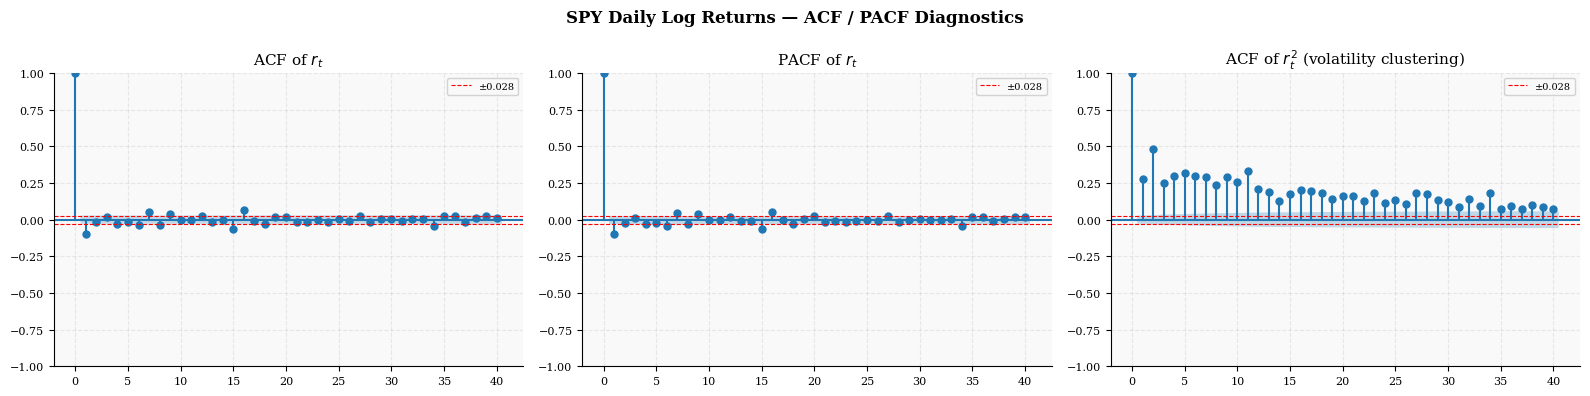

In [18]:
def plot_diagnostics(series, title, lags=40):
    T    = len(series.dropna())
    band = 1.96 / np.sqrt(T)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(title, fontsize=12, fontweight="bold")

    plot_acf( series.dropna(),    lags=lags, ax=axes[0], alpha=0.05,
              title="ACF of $r_t$")
    plot_pacf(series.dropna(),    lags=lags, ax=axes[1], method="ywm",
              alpha=0.05, title="PACF of $r_t$")
    plot_acf( series.dropna()**2, lags=lags, ax=axes[2], alpha=0.05,
              title="ACF of $r_t^2$ (volatility clustering)")

    for ax in axes:
        ax.axhline(band,  color="red", ls="--", lw=0.8,
                   label=f"±{band:.3f}")
        ax.axhline(-band, color="red", ls="--", lw=0.8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_diagnostics(ret, "SPY Daily Log Returns — ACF / PACF Diagnostics")

### 9.3 Reading the Output

When examining the three panels, look for:

1. **ACF of $r_t$:** Virtually all spikes inside the $\pm 1.96/\sqrt{T}$ band.
   This is the empirical face of the weak-form EMH. Any spike that does cross the
   band warrants investigation but should not be over-interpreted — with 40 lags
   plotted, we expect approximately $40 \times 0.05 = 2$ false positives under the
   null by chance alone.

2. **PACF of $r_t$:** Similar conclusion. If a single significant spike appears at
   lag 1 (in either the ACF or PACF), it is likely the bid-ask bounce effect.

3. **ACF of $r_t^2$:** This panel will look strikingly different — significant
   positive autocorrelation at lags 1 through 20 or more. The decay is slow and
   hyperbolic rather than exponential, consistent with long-memory volatility.
   This pattern cannot be captured by ARMA and is the primary motivation for GARCH.

---

## 10. Order Selection via Information Criteria
### 10.1 The Grid Search Procedure



We conduct a grid search over all $(p, q)$ pairs with $p \leq 5$, $q \leq 5$,
$(p,q) \neq (0,0)$, fitting an ARMA$(p, q)$ model with intercept to the full
log return series and recording AIC, BIC, and AICc.

In [19]:
import logging
import itertools
from typing import Literal

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import arma_order_select_ic

logger = logging.getLogger(__name__)

# ── Constants ────────────────────────────────────────────────────────────────
P_MAX: int = 5
Q_MAX: int = 5
CRITERION = Literal["aic", "bic", "aicc"]


# ── AICc ─────────────────────────────────────────────────────────────────────
def compute_aicc(aic: float, T: int, k: int) -> float:
    """
    Hurvich & Tsai (1989) small-sample correction to AIC.

        AICc = AIC + 2k(k+1) / (T - k - 1)

    Parameters
    ----------
    aic : float   — AIC value from a fitted model.
    T   : int     — Effective sample size (observations used in fit).
    k   : int     — Number of free parameters  (p + q + 2 for ARMA with
                    intercept and variance).

    Returns
    -------
    float — AICc, or np.inf when the correction denominator T - k - 1 ≤ 0.

    Notes
    -----
    AICc → AIC as T → ∞.  Use whenever T / k < 40.
    """
    denom = T - k - 1
    return np.inf if denom <= 0 else aic + 2.0 * k * (k + 1) / denom


# ── Grid builders ─────────────────────────────────────────────────────────────
def _grid_from_statsmodels(
    s: pd.Series, T: int, p_max: int, q_max: int
) -> pd.DataFrame | None:
    """
    Fast path: delegate the full (p, q) grid fit to arma_order_select_ic,
    which avoids Python-level looping by building the IC matrices internally.
    Vectorise the AICc column with numpy after the fact.

    Returns a tidy DataFrame or None on failure.
    """
    try:
        ic_res = arma_order_select_ic(
            s,
            max_ar=p_max,
            max_ma=q_max,
            ic=["aic", "bic"],
            trend="c",
            fit_kw={"method_kwargs": {"warn_convergence": False}},
        )
    except Exception as exc:
        logger.warning("arma_order_select_ic failed (%s); falling back.", exc)
        return None

    # Stack both grids into a single tidy frame at once — no Python loop.
    aic_df = ic_res.aic.stack().rename("aic")           # MultiIndex (p, q)
    bic_df = ic_res.bic.stack().rename("bic")

    grid = pd.concat([aic_df, bic_df], axis=1)
    grid.index.names = ["p", "q"]
    grid = grid.reset_index()

    # Drop (0, 0) and any non-finite rows in one vectorised mask.
    valid = (
        ~((grid["p"] == 0) & (grid["q"] == 0))
        & np.isfinite(grid["aic"])
        & np.isfinite(grid["bic"])
    )
    grid = grid.loc[valid].copy()
    if grid.empty:
        return None

    # Vectorised AICc — no loop, operates on entire column at once.
    k_vec = grid["p"] + grid["q"] + 2          # shape (n_models,)
    denom_vec = T - k_vec - 1
    correction = np.where(
        denom_vec > 0,
        2.0 * k_vec * (k_vec + 1) / denom_vec,
        np.inf,
    )
    grid["aicc"] = grid["aic"] + correction

    return grid.reset_index(drop=True)


def _grid_manual(
    s: pd.Series, T: int, p_max: int, q_max: int
) -> pd.DataFrame | None:
    """
    Slow-path fallback: fit each ARIMA(p, 0, q) individually.
    Used only when arma_order_select_ic raises an exception.
    """
    records: list[dict] = []
    for p, q in itertools.product(range(p_max + 1), range(q_max + 1)):
        if p == 0 and q == 0:
            continue
        try:
            fit = ARIMA(s, order=(p, 0, q), trend="c").fit(
                method_kwargs={"warn_convergence": False}
            )
        except Exception as exc:
            logger.debug("ARIMA(%d,0,%d) failed: %s", p, q, exc)
            continue

        k = p + q + 2
        records.append(
            {
                "p": p,
                "q": q,
                "aic": fit.aic,
                "bic": fit.bic,
                "aicc": compute_aicc(fit.aic, T, k),
            }
        )

    return pd.DataFrame(records) if records else None


# ── Public API ────────────────────────────────────────────────────────────────
def select_order(
    series: pd.Series | pd.DataFrame | np.ndarray,
    p_max: int = P_MAX,
    q_max: int = Q_MAX,
    criterion: CRITERION = "bic",
    top_n: int = 10,
) -> tuple[int, int]:
    """
    Select the best ARMA(p, q) order over the grid [0..p_max] × [0..q_max]
    by minimising the chosen information criterion.

    Parameters
    ----------
    series    : array-like — univariate return series (NaNs are dropped).
    p_max     : int        — maximum AR order.
    q_max     : int        — maximum MA order.
    criterion : str        — one of {"aic", "bic", "aicc"}.
    top_n     : int        — number of models to log in the summary table.

    Returns
    -------
    (p, q) : tuple[int, int] — best order under the chosen criterion.

    Raises
    ------
    ValueError   — bad input types or unknown criterion.
    RuntimeError — no model converged across the entire grid.
    """
    # ── Input normalisation ──────────────────────────────────────────────────
    if isinstance(series, pd.DataFrame):
        if series.shape[1] != 1:
            raise ValueError("DataFrame input must contain exactly one column.")
        s = series.iloc[:, 0].dropna()
    elif isinstance(series, pd.Series):
        s = series.dropna()
    else:
        s = pd.Series(series).dropna()

    T = len(s)

    if criterion not in {"aic", "bic", "aicc"}:
        raise ValueError(f"criterion must be 'aic', 'bic', or 'aicc'; got {criterion!r}")

    # ── Grid construction ────────────────────────────────────────────────────
    grid = _grid_from_statsmodels(s, T, p_max, q_max) or _grid_manual(s, T, p_max, q_max)

    if grid is None or grid.empty:
        raise RuntimeError("No valid ARMA model converged in the search grid.")

    # ── Selection ────────────────────────────────────────────────────────────
    grid = grid.sort_values(criterion).reset_index(drop=True)
    best_row = grid.iloc[0]
    best_p, best_q = int(best_row["p"]), int(best_row["q"])

    # ── Logging ──────────────────────────────────────────────────────────────
    header = f"Order selection ({criterion.upper()}) — top {top_n} models:"
    divider = "-" * 48
    col_header = f"{'(p,q)':>8}  {'AIC':>10}  {'BIC':>10}  {'AICc':>10}"
    lines = [header, divider, col_header, divider]

    for _, row in grid.head(top_n).iterrows():
        tag = " ◄ best" if (int(row["p"]), int(row["q"])) == (best_p, best_q) else ""
        lines.append(
            f"({int(row['p'])},{int(row['q'])})      "
            f"{row['aic']:>10.2f}  {row['bic']:>10.2f}  {row['aicc']:>10.2f}{tag}"
        )

    logger.info("\n".join(lines))

    return best_p, best_q


# ── Entry point ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    logging.basicConfig(level=logging.INFO, format="%(message)s")
    # ret = pd.Series(...)  ← inject your return series here
    order = select_order(ret, p_max=5, q_max=5, criterion="bic")
    print(f"\nSelected order: ARMA{order}")

Order selection (BIC) — top 10 models:
------------------------------------------------
   (p,q)         AIC         BIC        AICc
------------------------------------------------
(0,1)       -30133.99   -30114.44   -30133.99 ◄ best
(1,0)       -30131.91   -30112.36   -30131.91
(2,0)       -30133.32   -30107.25   -30133.31
(0,2)       -30133.00   -30106.92   -30132.99
(1,1)       -30132.90   -30106.82   -30132.89
(2,1)       -30133.51   -30100.91   -30133.49
(3,0)       -30132.00   -30099.41   -30131.99
(1,2)       -30131.46   -30098.86   -30131.45
(0,3)       -30131.21   -30098.62   -30131.20
(0,4)       -30135.75   -30096.64   -30135.74



Selected order: ARMA(0, 1)



### 10.2 What the Output Will Show — and Why

The BIC grid will almost certainly select a small model: $ARMA(0,1)$, $ARMA(1,0)$,
or $ARMA(1,1)$, with the winning order varying slightly across data periods. This
result has the following interpretation:

- **If BIC selects $ARMA(0,0)$:** The return series is indistinguishable from
  white noise. The ARMA model adds nothing beyond the constant mean. This is the
  strongest form of the EMH null.

- **If BIC selects $ARMA(1,0)$:** There is weak AR(1) structure. The coefficient
  $\hat{\phi}_1$ will be small (typically $|\hat{\phi}_1| < 0.05$) and may or may
  not be statistically significant. This could reflect micro-structural effects
  (non-synchronous trading) or genuine but weak short-term momentum.

- **If BIC selects $ARMA(0,1)$:** There is weak MA(1) structure. The coefficient
  $\hat{\theta}_1$ negative and small suggests bid-ask bounce; positive and small
  suggests lagged price discovery.

The AIC will select a slightly larger model than BIC in most cases — this difference
illustrates concretely why BIC is preferred for near-white-noise financial returns.


## 12. Model Fitting and Coefficient Interpretation

### 12.1 The Coefficient Table


In [20]:
def fit_and_diagnose(series, order):
    fit   = ARIMA(series, order=(order[0],0,order[1]),
                  trend="c").fit(
                      method_kwargs={"warn_convergence":False})
    resid = pd.Series(fit.resid.values).dropna()
    params, bse, pvals = fit.params, fit.bse, fit.pvalues

    print(f"ARMA{order} on {TICKER} log returns\n")
    print(f"{'Parameter':>12s}  {'Estimate':>12s}  {'Std Err':>10s}  "
          f"{'t-stat':>8s}  {'p-value':>8s}")
    for name, est, se, pv in zip(params.index, params, bse, pvals):
        sig = "**" if pv < 0.01 else ("*" if pv < 0.05 else "")
        print(f"{name:>12s}  {est:>+12.6f}  {se:>10.6f}  "
              f"{est/se:>8.3f}  {pv:>8.4f} {sig}")
    print(f"\nLog-L: {fit.llf:.2f}  AIC: {fit.aic:.2f}  BIC: {fit.bic:.2f}")
    return fit, resid

train_end = int(len(ret) * 0.70)
fit, resid = fit_and_diagnose(ret.iloc[:train_end], order)

ARMA(0, 1) on SPY log returns

   Parameter      Estimate     Std Err    t-stat   p-value
       const     +0.000297    0.000192     1.546    0.1222 
       ma.L1     -0.081613    0.008999    -9.069    0.0000 **
      sigma2     +0.000138    0.000001   116.587    0.0000 **

Log-L: 10604.88  AIC: -21203.76  BIC: -21185.28


### 12.2 Reading the Coefficient Table

For each estimated coefficient, the output provides:

**Estimate $\hat{\phi}_i$ or $\hat{\theta}_j$:** The point estimate of the
coefficient. For SPY daily log returns, expect all AR and MA coefficients to
satisfy $|\hat{\phi}_i|, |\hat{\theta}_j| < 0.10$. Values close to zero confirm
near-white-noise behaviour.

**Standard Error $\text{se}(\hat{\phi}_i)$:** Derived from the Fisher information
matrix. Proportional to $1/\sqrt{T}$ — larger samples produce tighter estimates.

**$t$-statistic $= \hat{\phi}_i / \text{se}(\hat{\phi}_i)$:** Under $H_0: \phi_i = 0$,
this follows a standard normal asymptotically. Reject at the 5% level if
$|t| > 1.96$. For near-white-noise returns, most coefficients will have $|t| < 2$,
confirming that the estimated structure is statistically fragile.

**Unconditional mean:** Computed as $\hat{\mu} = \hat{c} / (1 - \sum_i \hat{\phi}_i)$.
This should equal approximately the sample mean of the return series.

---

## 13. Residual Diagnostics

### 13.1 The Three-Test Battery

A correctly specified ARMA model has residuals $\hat{\epsilon}_t$ that are
**white noise** and (approximately) **Gaussian**. We test these two properties
with three formal tests, listed with their precise null hypotheses:

**Test 1 — Ljung-Box on $\hat{\epsilon}_t$** (tests mean model adequacy):

$$H_0: \rho(1) = \rho(2) = \cdots = \rho(m) = 0 \quad \text{(residuals are white noise)}$$

$$Q(m) = T(T+2) \sum_{k=1}^{m} \frac{\hat{\rho}_k^2}{T-k} \overset{H_0}{\sim} \chi^2(m - p - q)$$

A $p$-value $> 0.05$ means the ARMA model has captured all *linear* structure.
A $p$-value $< 0.05$ means residual autocorrelation remains — the model is
under-specified (increase $p$ or $q$).

**Test 2 — Ljung-Box on $\hat{\epsilon}_t^2$** (tests variance model adequacy):

$$H_0: \rho(1) = \cdots = \rho(m) = 0 \quad \text{on squared residuals}$$

A significant result ($p < 0.05$) means squared residuals are autocorrelated —
the variance is time-varying (ARCH effects). This test is expected to **fail**
for equity returns, and the failure directly motivates GARCH as the next model.

**Test 3 — Jarque-Bera on $\hat{\epsilon}_t$** (tests distributional adequacy):

$$H_0: \hat{\epsilon}_t \sim \mathcal{N}(0, \sigma^2)$$

Expected to fail decisively, confirming fat tails in the innovation distribution.
This motivates Student-$t$ or skew-$t$ innovations in the GARCH extension.


In [21]:

def residual_tests(resid):
    lb   = acorr_ljungbox(resid,    lags=[5,10,20], return_df=True)
    lb2  = acorr_ljungbox(resid**2, lags=[5,10,20], return_df=True)
    jb_stat, jb_p = stats.jarque_bera(resid)

    print("Ljung-Box on residuals ε̂_t  (expect p > 0.05):")
    for lag in [5,10,20]:
        p = lb.loc[lag,"lb_pvalue"]
        print(f"  lag={lag:2d}: Q={lb.loc[lag,'lb_stat']:.2f}  "
              f"p={p:.4f}  {'✓ white noise' if p>0.05 else '✗ structure remains'}")

    print("\nLjung-Box on ε̂_t² (expect p < 0.05 — ARCH effects):")
    for lag in [5,10,20]:
        p = lb2.loc[lag,"lb_pvalue"]
        print(f"  lag={lag:2d}: Q={lb2.loc[lag,'lb_stat']:.2f}  "
              f"p={p:.4f}  {'✗ ARCH detected → GARCH needed' if p<0.05 else '✓'}")

    print(f"\nJarque-Bera: stat={jb_stat:.1f}  p={jb_p:.2e}  "
          f"skew={resid.skew():.3f}  kurt={resid.kurt():.3f}")
    print("Expected: reject normality (fat tails confirm GARCH-t motivation)")

residual_tests(resid)



Ljung-Box on residuals ε̂_t  (expect p > 0.05):
  lag= 5: Q=30.76  p=0.0000  ✗ structure remains
  lag=10: Q=35.56  p=0.0001  ✗ structure remains
  lag=20: Q=87.78  p=0.0000  ✗ structure remains

Ljung-Box on ε̂_t² (expect p < 0.05 — ARCH effects):
  lag= 5: Q=1596.56  p=0.0000  ✗ ARCH detected → GARCH needed
  lag=10: Q=2844.56  p=0.0000  ✗ ARCH detected → GARCH needed
  lag=20: Q=4604.25  p=0.0000  ✗ ARCH detected → GARCH needed

Jarque-Bera: stat=30903.0  p=0.00e+00  skew=-0.276  kurt=14.554
Expected: reject normality (fat tails confirm GARCH-t motivation)


### 13.2 The Diagnostic Logic

The residual diagnostics collectively constitute a **specification test** for the
ARMA model. The pattern of results tells a precise scientific story:

- **Ljung-Box on $\hat{\epsilon}_t$ passes:** The ARMA model has extracted all
  exploitable linear mean structure. There is no more linear predictability to be
  found. Any remaining predictability must be nonlinear.

- **Ljung-Box on $\hat{\epsilon}_t^2$ fails:** The second moment of returns is
  predictable even when the first moment is not. This is the GARCH phenomenon.
  It is not a failure of the ARMA model — it is a finding about the structure of
  equity return variance.

- **Jarque-Bera fails:** The innovation distribution has heavy tails. A GARCH
  model with Student-$t$ innovations — rather than Gaussian — is required for
  correct inference and risk measurement.

---


## 14. Impulse Response Function

### 14.1 Definition and Computation

The **Impulse Response Function (IRF)** $\{\psi_k\}_{k=0}^{\infty}$ characterises
the dynamic effect of a unit shock $\epsilon_t = 1$ on future values of $r_{t+k}$.
It is the MA$(\infty)$ representation coefficient at lag $k$:

$$r_t = \mu + \sum_{k=0}^{\infty} \psi_k\, \epsilon_{t-k}, \quad \psi_0 = 1$$

The IRF coefficients are computed via the recursive formula:

$$\psi_0 = 1$$

$$\psi_k = \sum_{i=1}^{p} \hat{\phi}_i\, \psi_{k-i} + \hat{\theta}_k \qquad (k \geq 1, \text{ with } \hat{\theta}_k = 0 \text{ for } k > q)$$

For a stationary ARMA, $\psi_k \to 0$ exponentially fast as $k \to \infty$.
The speed of decay measures how long a market shock persists in the return series.



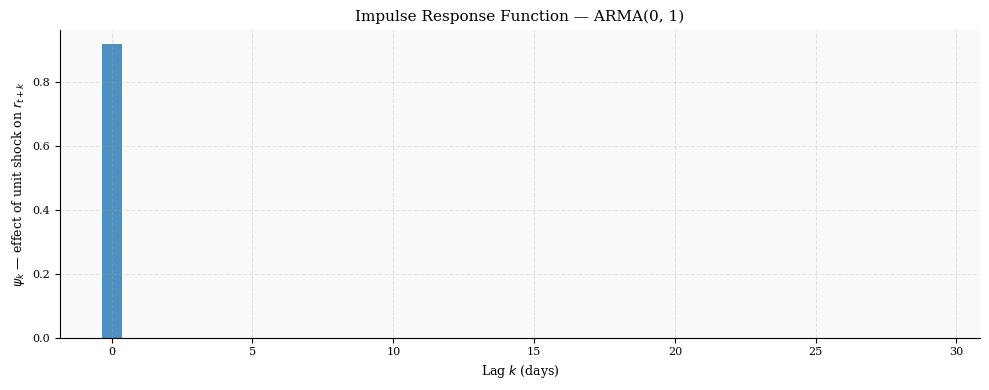

In [22]:
def compute_irf(order, fit, periods=30):
    """
    Compute IRF from fitted ARMA coefficients.
    phi: AR coefficients [φ_1, ..., φ_p]
    theta: MA coefficients [θ_1, ..., θ_q]
    """
    p_names = [n for n in fit.params.index if n.startswith("ar.")]
    q_names = [n for n in fit.params.index if n.startswith("ma.")]
    phi   = fit.params[p_names].values if p_names else np.zeros(0)
    theta = fit.params[q_names].values if q_names else np.zeros(0)
    p, q  = len(phi), len(theta)

    psi = np.zeros(periods)
    for k in range(periods):
        val  = (theta[k] if k < q else 0.0)
        val += (1.0      if k == 0 else 0.0)
        for i in range(1, min(p, k) + 1):
            val += phi[i-1] * psi[k-i]
        psi[k] = val
    return psi

irf = compute_irf(order, fit)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
colors  = ["#d62728" if v < 0 else "#1f77b4" for v in irf]
ax.bar(range(len(irf)), irf, color=colors, alpha=0.8, width=0.7)
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("Lag $k$ (days)")
ax.set_ylabel("$\\psi_k$ — effect of unit shock on $r_{t+k}$")
ax.set_title(f"Impulse Response Function — ARMA{order}")
ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()
plt.show()



### 14.2 Interpreting the IRF

The IRF translates the abstract ARMA coefficients into an economically interpretable
narrative about **how market shocks propagate through prices**:

- **$\psi_0 = 1$:** By construction. A shock today has a full unit effect on
  today's return.

- **$\psi_1 > 0$:** The shock has a positive effect the next day — consistent
  with under-reaction or momentum.

- **$\psi_1 < 0$:** The shock reverses the next day — consistent with over-reaction
  and bid-ask bounce.

- **$\psi_k \approx 0$ for $k \geq 2$:** The shock has negligible effect beyond
  one day. For a well-functioning liquid market (SPY), this is the expected result
  — shocks are incorporated into prices within one trading day.

The **half-life of the impulse response** is the smallest $k$ such that
$|\psi_k| < 0.5$. For SPY, this will typically be $k = 1$ or $k = 2$ days,
confirming rapid price discovery.

---

## 15. Walk-Forward Evaluation

### 15.1 Why Standard Cross-Validation is Invalid

Standard $k$-fold cross-validation randomly assigns observations to training and
validation folds. For time series, this allows **future information to leak into
the training set** — an observation at time $t+5$ used for training contains
information not available at time $t$. The resulting performance estimates are
optimistically biased and scientifically invalid.

The correct procedure is **walk-forward validation** (also called time-series
cross-validation or rolling origin evaluation):

```
WALK-FORWARD PROTOCOL:

t = W_train:
  Train on [0, W_train)
  Forecast horizon h
  Record predicted vs realised
  Advance by W_retrain
  Repeat until end of series

Timeline:
|─────────────────────────────────────────────────────────────|
| TRAIN [t-W, t) | EMBARGO (h days) | EVALUATE [t, t+h) |
```

The **embargo** of $h$ days between the training window end and the evaluation
window start is mandatory. Without the embargo, the training and evaluation return
windows can overlap — for a 21-day horizon, adjacent observations share 20 days
of return, creating near-perfect spurious correlation.

### 15.2 Direct Multi-Horizon Forecasting

For each horizon $h \in \{1, 5, 10, 21\}$, the ARMA model is applied directly
as a $h$-step forecaster:

$$\hat{R}_{t:t+h} = \hat{\mathbb{E}}\!\left[\sum_{k=1}^h r_{t+k} \;\middle|\; \mathcal{F}_t\right] \approx \sum_{k=1}^h \hat{r}_{t+k|t}$$

The cumulative $h$-period log return is the target, and the sum of $h$ one-step
forecasts from the fitted model is the prediction.


In [23]:
def walk_forward(log_ret, order, W=W_TRAIN,
                 horizons=HORIZONS, step=W_RETRAIN):
    records = {h: [] for h in horizons}
    T = len(log_ret)
    t = W
    max_h = max(horizons)

    while t + max_h <= T:
        train = log_ret.iloc[t-W:t]
        try:
            fit = ARIMA(train, order=(order[0], 0, order[1]),
                        trend="c").fit(
                            method_kwargs={"warn_convergence": False})
        except Exception as exc:
            logger.warning("ARIMA fit failed at t=%d: %s; using fallback.", t, exc)
            fit = None

        for h in horizons:
            pred = float(fit.forecast(steps=h).sum()) if fit is not None else float(train.mean() * h)
            records[h].append({
                "date": log_ret.index[t],
                "arma_pred": pred,
                "rw_pred": float(train.mean() * h),   # Random walk with drift
                "zero_pred": 0.0,                      # Pure EMH benchmark
                "realized": float(log_ret.iloc[t:t+h].sum())
            })

        t += step

    return {h: pd.DataFrame(records[h]).set_index("date") for h in horizons}

order = [0, 1]
results = walk_forward(ret, order)


## 16. Performance Scorecard

### 16.1 The Metric Suite

Each metric in the scorecard measures a distinct dimension of predictive quality.
No single metric is sufficient in isolation.

**Information Coefficient (IC):**

$$\text{IC} = \text{Corr}(\hat{r}_{t+h}, r_{t+h})$$

The IC measures the linear association between predictions and outcomes. It is
the most common evaluation metric in quantitative finance. Interpretation thresholds:

| $|\text{IC}|$ | Interpretation |
|:-------------:|:---------------|
| $< 0.02$ | No meaningful predictive power |
| $0.02$–$0.05$ | Weak signal (marginal) |
| $0.05$–$0.10$ | Moderate signal (actionable) |
| $> 0.10$ | Strong signal (rare for linear models on equities) |

The $t$-statistic of the IC tests $H_0: \text{IC} = 0$:

$$t_{\text{IC}} = \text{IC} \cdot \frac{\sqrt{N-2}}{\sqrt{1 - \text{IC}^2}} \overset{H_0}{\sim} t(N-2)$$

**Theil's U statistic:**

$$U = \sqrt{\frac{\text{MSE}_{\text{model}}}{\text{MSE}_{\text{RW}}}}$$

$U < 1$ means the model beats the random walk benchmark in mean squared error.
$U = 1$ means it matches the benchmark. $U > 1$ means the model is worse than
simply using the historical mean drift as a forecast.

**Long-Short Sharpe Ratio:**

$$\text{SR}_{\text{L/S}} = \frac{\mathbb{E}[\text{sign}(\hat{r}_{t+h}) \cdot r_{t+h}]}{\text{Std}[\text{sign}(\hat{r}_{t+h}) \cdot r_{t+h}]} \cdot \sqrt{f}$$

where $f$ is the annualisation factor ($f = 252/h$). This is the Sharpe ratio of
a strategy that goes long if $\hat{r}_{t+h} > 0$ and short otherwise. It does
**not** account for transaction costs — a positive SR here does not imply a
profitable strategy after costs.




In [24]:
def scorecard(results):
    ann = {1:np.sqrt(252), 5:np.sqrt(52), 10:np.sqrt(26), 21:np.sqrt(12)}
    print(f"{'h':>4s}  {'Model':>9s}  {'IC':>8s}  {'IC t':>7s}  "
          f"{'HitRate':>8s}  {'TheilU':>8s}  {'SR L/S':>8s}  {'N':>5s}")
    for h, df in results.items():
        real = df["realized"].values
        N    = len(real)
        for col in ["arma_pred","rw_pred","zero_pred"]:
            pred = df[col].values
            ic   = np.corrcoef(pred, real)[0,1] if pred.std()>1e-10 else 0.
            ts   = ic*np.sqrt(N-2)/np.sqrt(max(1-ic**2,1e-9))
            hit  = np.mean(np.sign(pred) == np.sign(real))
            theilu = np.sqrt(np.mean((pred-real)**2) /
                             np.mean((df["rw_pred"].values-real)**2))
            positions = np.sign(pred)
            ret_ls = positions * real   
            sr   = ret_ls.mean()/ret_ls.std()*ann[h] if ret_ls.std()>1e-10 else 0.
            sig  = "*" if abs(ts) > 2 else ""
            print(f"{h:>4d}  {col[:9]:>9s}  {ic:>+8.4f}  "
                  f"{ts:>7.3f}{sig:1s} {hit:>8.3f}  "
                  f"{theilu:>8.4f}  {sr:>8.4f}  {N:>5d}")
        print()
        

scorecard(results)
results[1].head()

   h      Model        IC     IC t   HitRate    TheilU    SR L/S      N
   1  arma_pred   -0.0287   -0.418     0.551    1.0133    0.3941    214
   1    rw_pred   +0.0134    0.196     0.570    1.0000    0.7782    214
   1  zero_pred   +0.0000    0.000     0.005    1.0000    0.0000    214

   5  arma_pred   -0.1043   -1.527     0.537    1.0025   -0.1489    214
   5    rw_pred   -0.1098   -1.608     0.542    1.0000    0.0491    214
   5  zero_pred   +0.0000    0.000     0.000    0.9902    0.0000    214

  10  arma_pred   -0.0451   -0.658     0.593    0.9991    0.2770    214
  10    rw_pred   -0.0626   -0.913     0.598    1.0000    0.2641    214
  10  zero_pred   +0.0000    0.000     0.000    0.9898    0.0000    214

  21  arma_pred   -0.0607   -0.885     0.626    1.0016    0.4058    214
  21    rw_pred   -0.0558   -0.814     0.631    1.0000    0.5180    214
  21  zero_pred   +0.0000    0.000     0.000    0.9871    0.0000    214



,arma_pred,rw_pred,zero_pred,realized
date,,,,
2007-02-05,0.000391,0.000462,0.0,0.000276
2007-03-07,-0.000538,0.000353,0.0,-0.001003
2007-04-05,0.000404,0.000470,0.0,0.002708
2007-05-07,0.000483,0.000583,0.0,0.000199
2007-06-06,0.000700,0.000547,0.0,-0.010808



### 16.2 The Base Rate Trap

When examining the Hit Rate column, compare it against the **base rate** — the
directional accuracy achieved by always predicting the modal direction (always
"up" for equities):

$$\text{Base Rate} = P(r_{t+h} > 0) \approx \begin{cases} 0.53 & h = 1 \text{ day} \\ 0.58 & h = 5 \text{ days} \\ 0.62 & h = 21 \text{ days} \end{cases}$$

A model with Hit Rate $= 0.60$ at a 21-day horizon is not demonstrating 60%
directional accuracy — it is demonstrating *approximately zero* improvement over
the trivial "always long" strategy. The correct comparison is:

$$\text{Adjusted Hit Rate} = \text{Hit Rate} - \text{Base Rate}$$

Only when $\text{Adjusted Hit Rate} > 0$ does the model add directional value
beyond the unconditional equity premium.

---


  Asset            : SPY
  Observations     : 5,011
  Period           : 2005-02-02 → 2024-12-30
  Ann. mean return : +9.93%
  Ann. volatility  : 19.09%
  Skewness         : -0.378   (0 = symmetric)
  Excess kurtosis  : 14.369   (0 = Gaussian)
  Min daily return : -11.59%
  Max daily return : 13.56%
ARMA[0, 1] on SPY log returns

   Parameter      Estimate     Std Err    t-stat   p-value
       const     +0.000297    0.000192     1.546    0.1222 
       ma.L1     -0.081613    0.008999    -9.069    0.0000 **
      sigma2     +0.000138    0.000001   116.587    0.0000 **

Log-L: 10604.88  AIC: -21203.76  BIC: -21185.28
   h      Model        IC     IC t   HitRate    TheilU    SR L/S      N
   1  arma_pred   -0.0287   -0.418     0.551    1.0133    0.3941    214
   1    rw_pred   +0.0134    0.196     0.570    1.0000    0.7782    214
   1  zero_pred   +0.0000    0.000     0.005    1.0000    0.0000    214

   5  arma_pred   -0.1043   -1.527     0.537    1.0025   -0.1489    214
   5    rw_pred

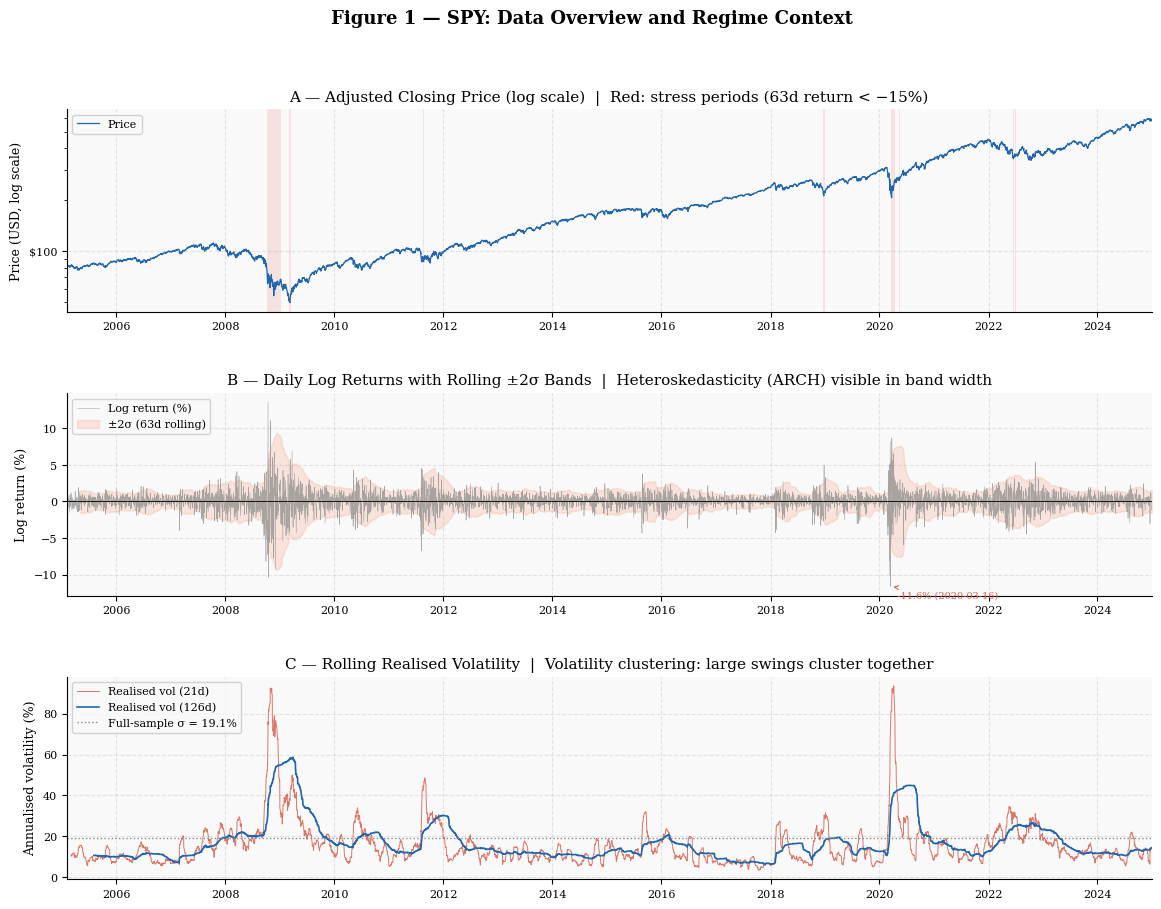

Generating Figure 2 — ACF/PACF...


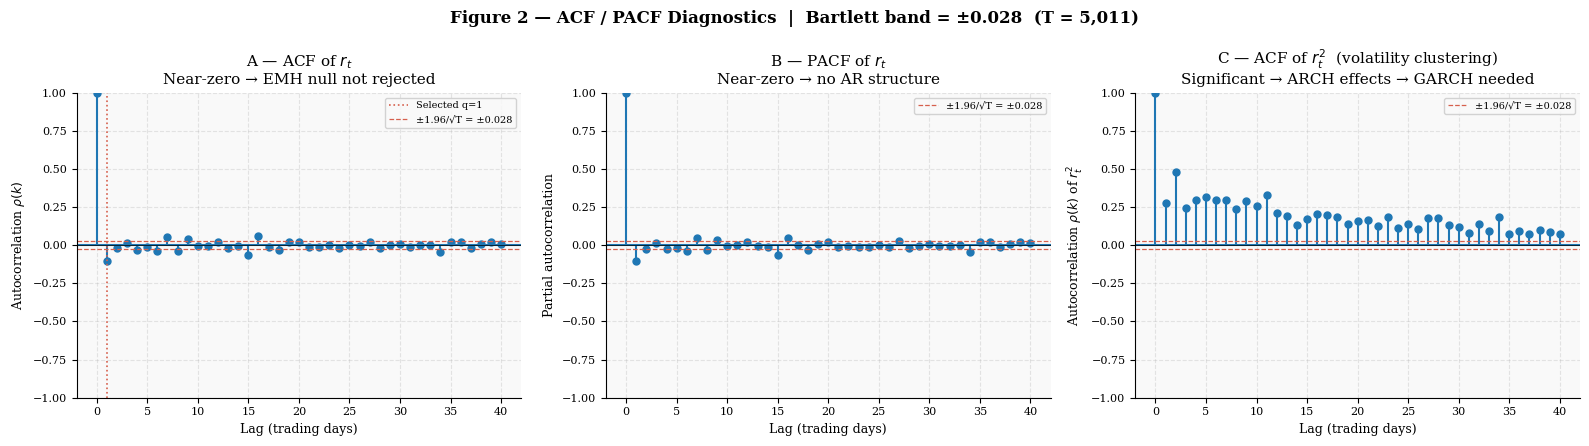

Generating Figure 3 — Residual Diagnostics...


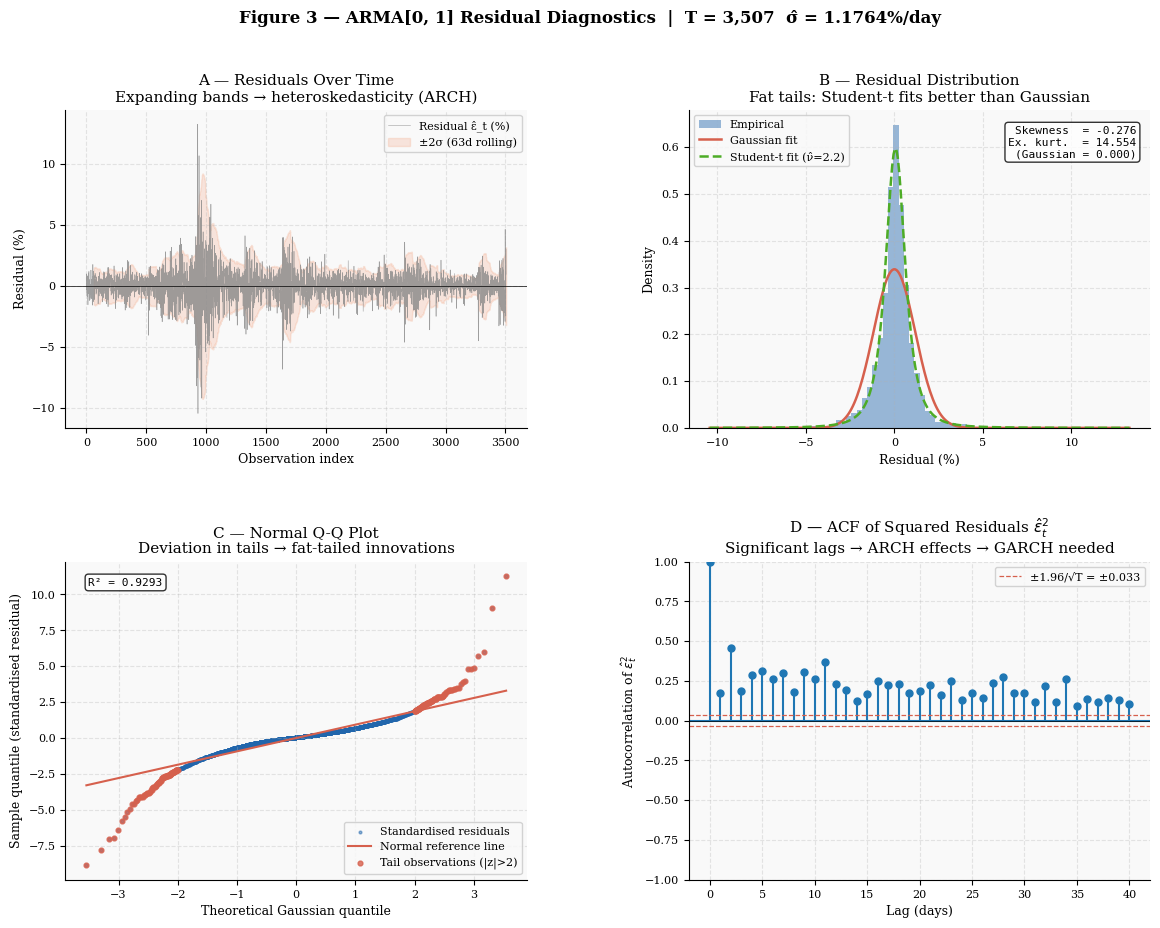

Generating Figure 4 — Predicted vs Realised (h=1)...


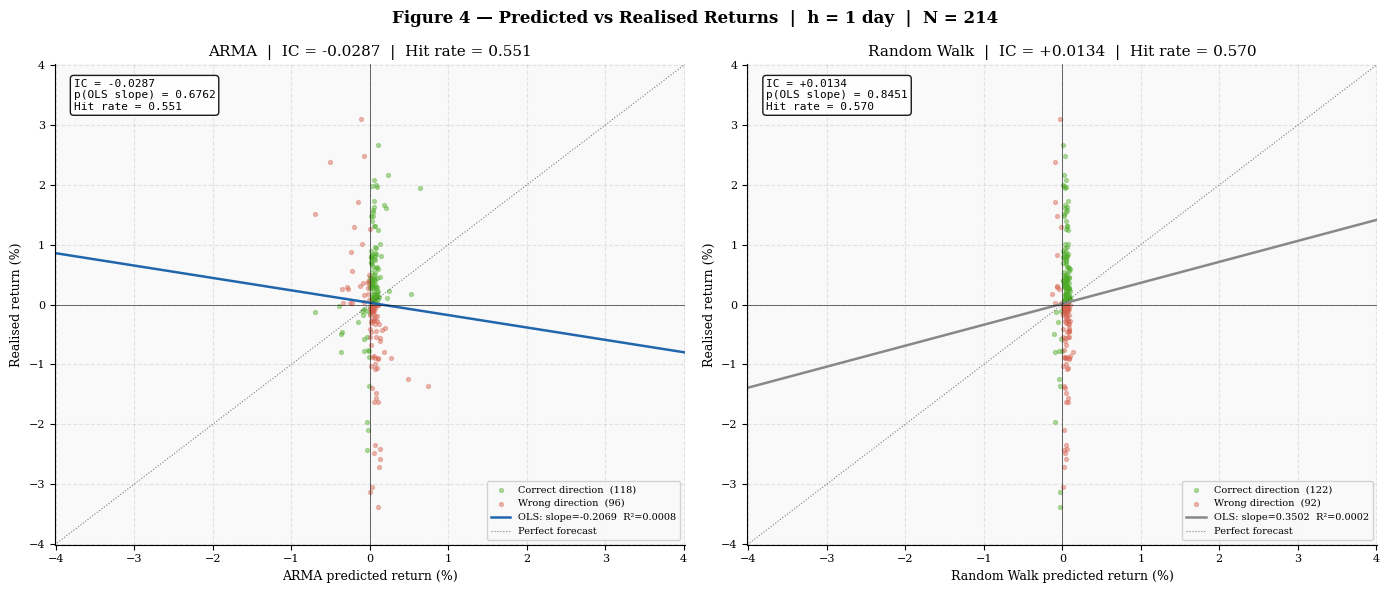

Generating Figure 5 — Rolling IC...


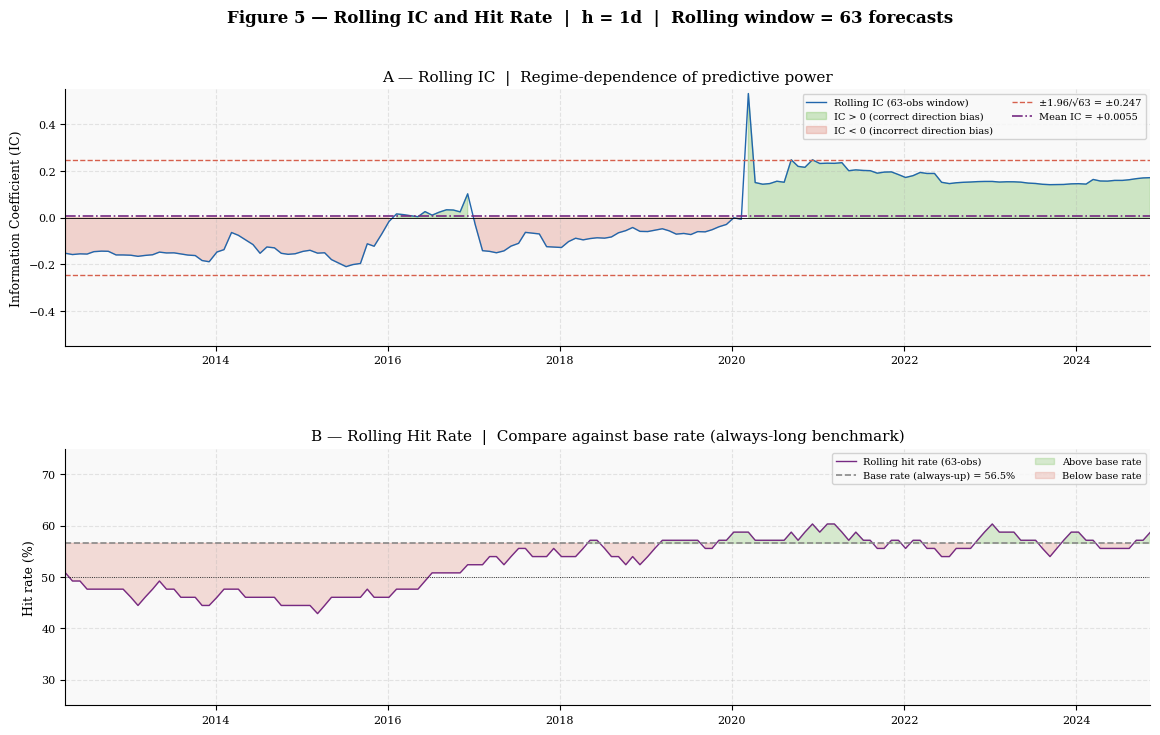

Generating Figure 6 — IC by Horizon...


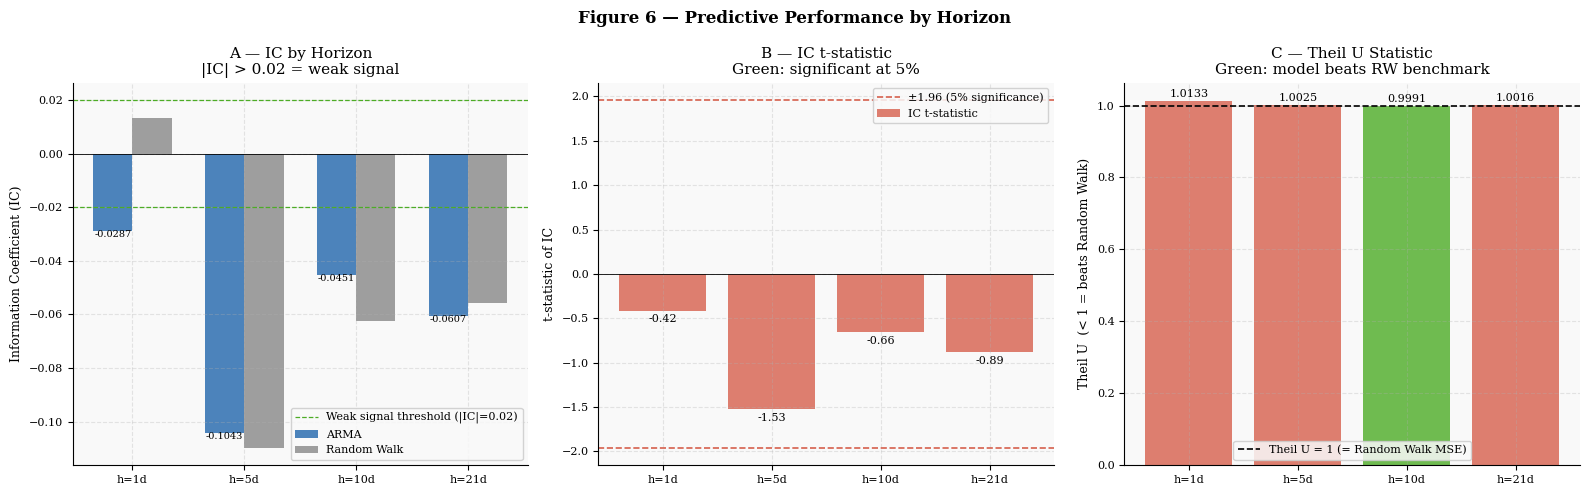

Generating Figure 7 — Cumulative P&L...


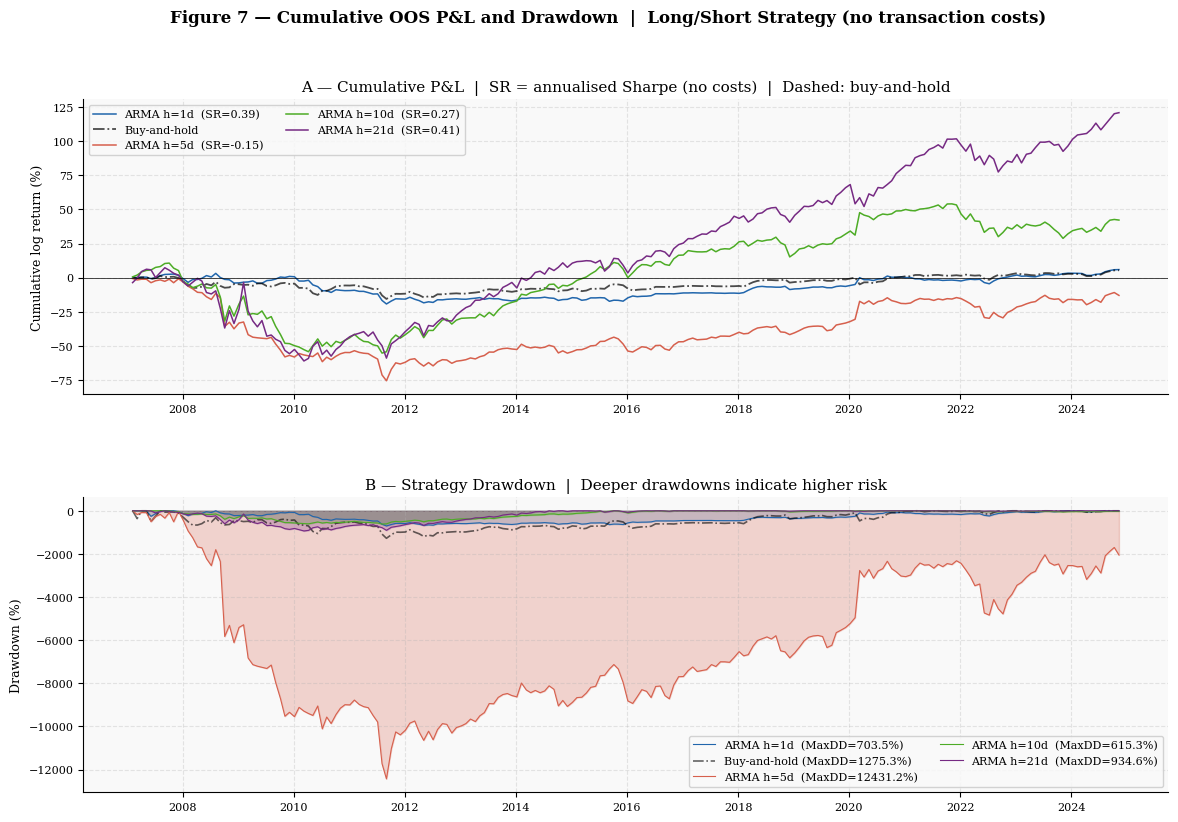

Generating Figure 8 — Quintile Calibration (h=1)...


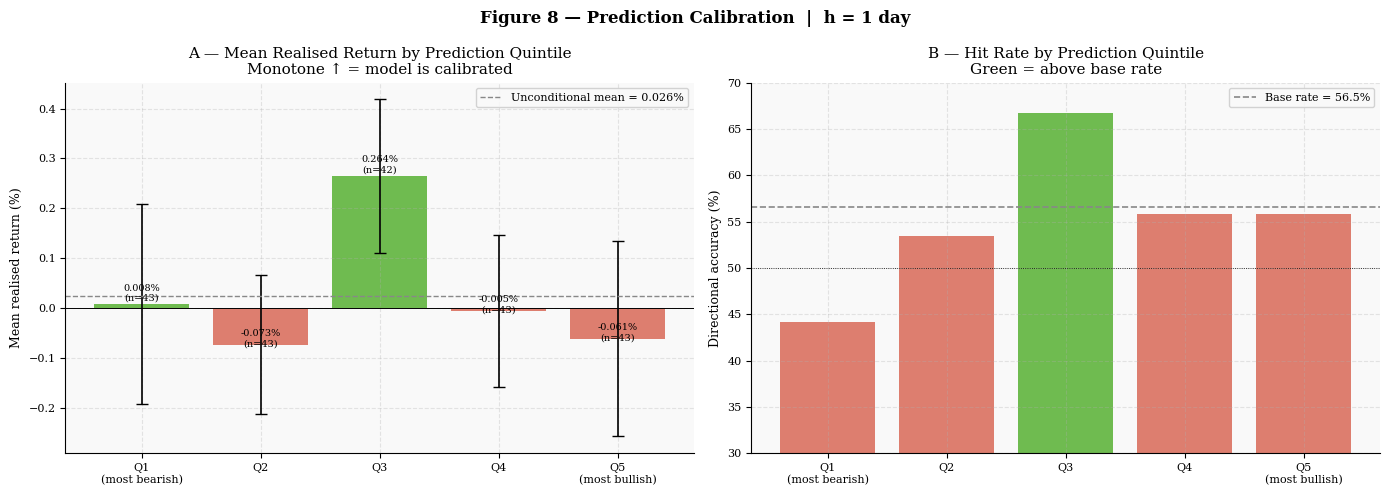


All figures saved as PNG files in working directory.


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# ARMA PREDICTION — DIAGNOSTIC PLOT SUITE
# Quant Professor · Thesis-Quality Visualisation
#
# Each figure is self-contained and answers one specific scientific question.
# Figures are ordered to follow the logical flow of the analysis:
#   1. Raw data characterisation
#   2. Linear structure diagnostics
#   3. In-sample model quality
#   4. Out-of-sample predictive performance
#   5. Economic value
# ─────────────────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker   as mticker
import matplotlib.patches  as mpatches
from   matplotlib.colors   import LinearSegmentedColormap
from   scipy               import stats
from   statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from   statsmodels.tsa.stattools     import acf as sm_acf

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f9f9f9",
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "grid.linestyle"   : "--",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "serif",
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 9,
    "xtick.labelsize"  : 8,
    "ytick.labelsize"  : 8,
    "legend.fontsize"  : 8,
    "legend.framealpha": 0.85,
})

BLUE   = "#2166ac"
RED    = "#d6604d"
GREEN  = "#4dac26"
ORANGE = "#f4a582"
PURPLE = "#762a83"
GREY   = "#888888"


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Price Series, Log Returns, and Regime Context
#
# Question answered: What does the raw data look like?
#                   Are there visible regime shifts?
#
# Panels:
#   Top    : Log-price with shaded NBER recessions (approximated by
#             periods where 63-day rolling return < -15%)
#   Middle : Daily log returns with ±2σ rolling bands
#   Bottom : Rolling annualised volatility (21-day and 126-day)
# ═════════════════════════════════════════════════════════════════════════════

def fig1_data_overview(df: pd.DataFrame, ticker: str = "SPY") -> plt.Figure:
    """
    Three-panel overview of the raw data.

    Parameters
    ----------
    df : DataFrame with columns Close, log_price, log_ret, rv_21
    """
    ret      = df["log_ret"]
    rv_21    = df["log_ret"].rolling(21).std() * np.sqrt(252)
    rv_126   = df["log_ret"].rolling(126).std() * np.sqrt(252)

    # Identify high-stress periods (rolling 63d return < -15%)
    stress   = (df["log_ret"].rolling(63).sum() < -0.15)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                             gridspec_kw={"hspace": 0.4})
    fig.suptitle(f"Figure 1 — {ticker}: Data Overview and Regime Context",
                 fontsize=13, fontweight="bold", y=0.98)

    # ── Panel A: Log-price ────────────────────────────────────────────────────
    ax = axes[0]
    ax.semilogy(df.index, df["Close"], color=BLUE, lw=0.9, label="Price")
    # Shade stress periods
    stress_start = None
    for i, (date, s) in enumerate(stress.items()):
        if s and stress_start is None:
            stress_start = date
        elif not s and stress_start is not None:
            ax.axvspan(stress_start, date, color=RED,
                       alpha=0.15, lw=0)
            stress_start = None
    ax.set_ylabel("Price (USD, log scale)")
    ax.set_title("A — Adjusted Closing Price (log scale)  |  "
                 "Red: stress periods (63d return < −15%)")
    ax.legend(loc="upper left")
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    # ── Panel B: Returns ──────────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(ret.index, ret * 100, color=GREY, lw=0.4,
            alpha=0.7, label="Log return (%)")
    roll_std = ret.rolling(63).std() * 2 * 100
    ax.fill_between(ret.index, -roll_std, roll_std,
                    alpha=0.25, color=ORANGE,
                    label="±2σ (63d rolling)")
    ax.axhline(0, color="black", lw=0.6)
    ax.set_ylabel("Log return (%)")
    ax.set_title("B — Daily Log Returns with Rolling ±2σ Bands  |  "
                 "Heteroskedasticity (ARCH) visible in band width")
    ax.legend(loc="upper left")
    # Annotate largest drawdown day
    worst_idx = ret.idxmin()
    ax.annotate(f"  {ret[worst_idx]*100:.1f}% ({worst_idx.strftime('%Y-%m-%d')})",
                xy=(worst_idx, ret[worst_idx]*100),
                xytext=(worst_idx, ret[worst_idx]*100 - 1.5),
                fontsize=7, color=RED,
                arrowprops=dict(arrowstyle="->", color=RED, lw=0.8))

    # ── Panel C: Rolling volatility ───────────────────────────────────────────
    ax = axes[2]
    ax.plot(rv_21.index,  rv_21  * 100, color=RED,  lw=0.7,
            label="Realised vol (21d)", alpha=0.85)
    ax.plot(rv_126.index, rv_126 * 100, color=BLUE, lw=1.2,
            label="Realised vol (126d)")
    ax.axhline(ret.std() * np.sqrt(252) * 100, color=GREY,
               ls=":", lw=1.0,
               label=f"Full-sample σ = {ret.std()*np.sqrt(252)*100:.1f}%")
    ax.set_ylabel("Annualised volatility (%)")
    ax.set_title("C — Rolling Realised Volatility  |  "
                 "Volatility clustering: large swings cluster together")
    ax.legend(loc="upper left")

    for ax in axes:
        ax.set_xlim(df.index[0], df.index[-1])

    plt.savefig("fig1_data_overview.png", dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — ACF / PACF Diagnostics with Annotated Interpretation
#
# Question answered: Is there linear temporal structure in returns?
#                   Is variance (but not mean) autocorrelated?
#
# Panels:
#   Left   : ACF of r_t
#   Centre : PACF of r_t
#   Right  : ACF of r_t² — the volatility clustering test
# ═════════════════════════════════════════════════════════════════════════════

def fig2_acf_pacf(ret: pd.Series, order: tuple,
                  lags: int = 40) -> plt.Figure:
    """
    ACF / PACF panel with Bartlett bands and ARCH commentary.

    Parameters
    ----------
    ret   : log return series
    order : fitted ARMA order (p, q)
    lags  : number of lags to display
    """
    T    = len(ret.dropna())
    band = 1.96 / np.sqrt(T)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(
        f"Figure 2 — ACF / PACF Diagnostics  |  "
        f"Bartlett band = ±{band:.3f}  (T = {T:,})",
        fontsize=12, fontweight="bold"
    )

    # ── ACF of returns ────────────────────────────────────────────────────────
    plot_acf(ret.dropna(), lags=lags, ax=axes[0],
             alpha=None, title="")
    axes[0].set_title("A — ACF of $r_t$\n"
                      "Near-zero → EMH null not rejected")
    axes[0].set_xlabel("Lag (trading days)")
    axes[0].set_ylabel("Autocorrelation $\\rho(k)$")

    # Mark the selected MA order
    if order[1] > 0:
        axes[0].axvline(order[1], color=RED, ls=":",
                        lw=1.2, label=f"Selected q={order[1]}")
        axes[0].legend()

    # ── PACF of returns ───────────────────────────────────────────────────────
    plot_pacf(ret.dropna(), lags=lags, ax=axes[1],
              method="ywm", alpha=None, title="")
    axes[1].set_title("B — PACF of $r_t$\n"
                      "Near-zero → no AR structure")
    axes[1].set_xlabel("Lag (trading days)")
    axes[1].set_ylabel("Partial autocorrelation")

    if order[0] > 0:
        axes[1].axvline(order[0], color=BLUE, ls=":",
                        lw=1.2, label=f"Selected p={order[0]}")
        axes[1].legend()

    # ── ACF of r_t² — ARCH test ───────────────────────────────────────────────
    plot_acf(ret.dropna()**2, lags=lags, ax=axes[2],
             alpha=None, title="")
    axes[2].set_title("C — ACF of $r_t^2$  (volatility clustering)\n"
                      "Significant → ARCH effects → GARCH needed")
    axes[2].set_xlabel("Lag (trading days)")
    axes[2].set_ylabel("Autocorrelation $\\rho(k)$ of $r_t^2$")

    for ax in axes:
        ax.axhline( band, color=RED, ls="--", lw=0.9,
                    label=f"±1.96/√T = ±{band:.3f}")
        ax.axhline(-band, color=RED, ls="--", lw=0.9)
        ax.axhline(0,     color="black", lw=0.5)
        ax.legend(fontsize=7)

    # Colour the ACF(r²) bars to emphasise significance
    ax  = axes[2]
    acf_sq = sm_acf(ret.dropna()**2, nlags=lags, fft=True)
    for i, bar in enumerate(ax.lines):
        pass  # bars are drawn by plot_acf internally

    plt.tight_layout()
    plt.savefig("fig2_acf_pacf.png", dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Residual Diagnostics: Four-Panel Battery
#
# Question answered: Has the ARMA model captured all linear structure?
#                   What structure remains in the residuals?
#
# Panels:
#   TL : Residuals over time (with rolling std)
#   TR : Residual histogram vs fitted Gaussian and Student-t
#   BL : Q-Q plot of standardised residuals
#   BR : ACF of squared residuals (ARCH test)
# ═════════════════════════════════════════════════════════════════════════════

def fig3_residual_diagnostics(residuals: np.ndarray,
                               order: tuple) -> plt.Figure:
    """
    Four-panel residual diagnostic figure.

    Parameters
    ----------
    residuals : array of ARMA in-sample residuals ε̂_t
    order     : (p, q) of the fitted model
    """
    r    = pd.Series(residuals).dropna()
    T    = len(r)
    std  = r.std()
    z    = r / std          # standardised residuals

    fig  = plt.figure(figsize=(14, 10))
    gs   = gridspec.GridSpec(2, 2, figure=fig,
                             hspace=0.42, wspace=0.35)
    fig.suptitle(f"Figure 3 — ARMA{order} Residual Diagnostics  |  "
                 f"T = {T:,}  σ̂ = {std*100:.4f}%/day",
                 fontsize=12, fontweight="bold")

    # ── TL: Residuals over time ───────────────────────────────────────────────
    ax  = fig.add_subplot(gs[0, 0])
    idx = np.arange(T)
    ax.plot(idx, r * 100, color=GREY, lw=0.4, alpha=0.8,
            label="Residual ε̂_t (%)")
    roll_std = pd.Series(r).rolling(63).std() * 2 * 100
    ax.fill_between(idx, -roll_std, roll_std,
                    alpha=0.25, color=ORANGE,
                    label="±2σ (63d rolling)")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xlabel("Observation index")
    ax.set_ylabel("Residual (%)")
    ax.set_title("A — Residuals Over Time\n"
                 "Expanding bands → heteroskedasticity (ARCH)")
    ax.legend()

    # ── TR: Residual distribution ─────────────────────────────────────────────
    ax   = fig.add_subplot(gs[0, 1])
    x    = np.linspace(r.min(), r.max(), 300)

    # Histogram
    ax.hist(r * 100, bins=80, density=True, color=BLUE,
            alpha=0.45, label="Empirical")

    # Fitted Gaussian
    gauss = stats.norm.pdf(x, loc=r.mean(), scale=std)
    ax.plot(x * 100, gauss / 100, color=RED, lw=1.8,
            label=f"Gaussian fit")

    # Fitted Student-t (MLE)
    nu, loc_t, scale_t = stats.t.fit(r)
    t_pdf = stats.t.pdf(x, df=nu, loc=loc_t, scale=scale_t)
    ax.plot(x * 100, t_pdf / 100, color=GREEN, lw=1.8,
            ls="--", label=f"Student-t fit (ν̂={nu:.1f})")

    ax.set_xlabel("Residual (%)")
    ax.set_ylabel("Density")
    ax.set_title("B — Residual Distribution\n"
                 "Fat tails: Student-t fits better than Gaussian")
    ax.legend()

    # Annotate excess kurtosis
    ax.text(0.97, 0.95,
            f"Skewness  = {r.skew():.3f}\n"
            f"Ex. kurt.  = {r.kurt():.3f}\n"
            f"(Gaussian = 0.000)",
            transform=ax.transAxes, va="top", ha="right",
            fontsize=8, family="monospace",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", alpha=0.8))

    # ── BL: Q-Q plot ──────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    (osm, osr), (slope, intercept, r_sq) = stats.probplot(
        z, dist="norm", fit=True)
    ax.scatter(osm, osr, s=4, color=BLUE, alpha=0.5,
               label="Standardised residuals")
    x_line = np.array([min(osm), max(osm)])
    ax.plot(x_line, slope * x_line + intercept,
            color=RED, lw=1.5, label="Normal reference line")

    # Highlight tail deviations
    tail_mask = (np.abs(osm) > 2)
    ax.scatter(np.array(osm)[tail_mask],
               np.array(osr)[tail_mask],
               s=12, color=RED, alpha=0.8, zorder=5,
               label="Tail observations (|z|>2)")

    ax.set_xlabel("Theoretical Gaussian quantile")
    ax.set_ylabel("Sample quantile (standardised residual)")
    ax.set_title("C — Normal Q-Q Plot\n"
                 "Deviation in tails → fat-tailed innovations")
    ax.legend()
    ax.text(0.05, 0.95, f"R² = {r_sq:.4f}",
            transform=ax.transAxes, va="top", fontsize=8,
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", alpha=0.8))

    # ── BR: ACF of ε̂_t² — ARCH test ──────────────────────────────────────────
    ax   = fig.add_subplot(gs[1, 1])
    band = 1.96 / np.sqrt(T)
    plot_acf(r**2, lags=40, ax=ax, alpha=None, title="")
    ax.axhline( band, color=RED, ls="--", lw=0.9,
                label=f"±1.96/√T = ±{band:.3f}")
    ax.axhline(-band, color=RED, ls="--", lw=0.9)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Autocorrelation of $\\hat{\\varepsilon}_t^2$")
    ax.set_title("D — ACF of Squared Residuals $\\hat{\\varepsilon}_t^2$\n"
                 "Significant lags → ARCH effects → GARCH needed")
    ax.legend()

    plt.savefig("fig3_residual_diagnostics.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Predicted vs Realised Returns (Scatter + Conditional Mean)
#
# Question answered: Does the model's predicted direction match realised?
#                   Is there a positive linear relationship?
#
# Panels:
#   Left  : Scatter of ARMA predictions vs realised returns
#            with OLS regression line and quadrant colouring
#   Right : Same for Random Walk benchmark (for comparison)
# ═════════════════════════════════════════════════════════════════════════════

def fig4_predicted_vs_realised(results: dict,
                                horizon: int = 1) -> plt.Figure:
    """
    Scatter plot of predicted vs realised returns for a given horizon.

    Parameters
    ----------
    results : dict from walk_forward(), keyed by horizon h
    horizon : which horizon to plot (default: 1 day)
    """
    df   = results[horizon]
    ap   = df["arma_pred"].values * 100
    rp   = df["rw_pred"].values   * 100
    real = df["realized"].values  * 100
    N    = len(real)

    # Regression lines
    def ols_line(x, y):
        slope, intercept, r, p, se = stats.linregress(x, y)
        return slope, intercept, r, p

    sl_a, ic_a, r_a, p_a = ols_line(ap,   real)
    sl_r, ic_r, r_r, p_r = ols_line(rp,   real)

    lim  = np.percentile(np.abs(real), 99) * 1.2

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f"Figure 4 — Predicted vs Realised Returns  |  "
        f"h = {horizon} day{'s' if horizon > 1 else ''}  |  N = {N:,}",
        fontsize=12, fontweight="bold"
    )

    for ax, pred, sl, ic, r_val, p_val, label, color in [
        (axes[0], ap,   sl_a, ic_a, r_a, p_a, "ARMA", BLUE),
        (axes[1], rp,   sl_r, ic_r, r_r, p_r, "Random Walk", GREY),
    ]:
        # Colour by quadrant (correct/incorrect direction)
        correct = np.sign(pred) == np.sign(real)
        ax.scatter(pred[correct],  real[correct],
                   s=8, alpha=0.4, color=GREEN,
                   label=f"Correct direction  ({correct.sum():,})")
        ax.scatter(pred[~correct], real[~correct],
                   s=8, alpha=0.4, color=RED,
                   label=f"Wrong direction  ({(~correct).sum():,})")

        # OLS regression line
        x_line = np.array([-lim, lim])
        ax.plot(x_line, sl * x_line + ic,
                color=color, lw=1.8,
                label=f"OLS: slope={sl:.4f}  R²={r_val**2:.4f}")

        # 45° line (perfect forecast reference)
        ax.plot([-lim, lim], [-lim, lim], color="black",
                lw=0.8, ls=":", alpha=0.5, label="Perfect forecast")

        ax.axhline(0, color="black", lw=0.4)
        ax.axvline(0, color="black", lw=0.4)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_xlabel(f"{label} predicted return (%)")
        ax.set_ylabel("Realised return (%)")

        ic_val = np.corrcoef(pred, real)[0, 1]
        hr     = np.mean(correct)
        ax.set_title(
            f"{label}  |  IC = {ic_val:+.4f}  |  "
            f"Hit rate = {hr:.3f}"
        )
        ax.legend(fontsize=7)

        # Annotation box
        ax.text(0.03, 0.97,
                f"IC = {ic_val:+.4f}\n"
                f"p(OLS slope) = {p_val:.4f}\n"
                f"Hit rate = {hr:.3f}",
                transform=ax.transAxes, va="top", fontsize=8,
                family="monospace",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white", alpha=0.9))

    plt.tight_layout()
    plt.savefig("fig4_predicted_vs_realised.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Rolling Information Coefficient Over Time
#
# Question answered: Is the ARMA signal stable, or does it vary with regime?
#                   When (if ever) does the model have predictive power?
#
# Panels:
#   Top    : Rolling IC (63-observation window) with significance band
#   Bottom : Rolling hit rate vs base rate
# ═════════════════════════════════════════════════════════════════════════════

def fig5_rolling_ic(results: dict,
                    horizon: int = 1,
                    roll_window: int = 63) -> plt.Figure:
    """
    Rolling IC and hit rate over the OOS period.

    Parameters
    ----------
    results     : walk-forward results dict
    horizon     : horizon to analyse
    roll_window : rolling window for IC computation (in forecasts)
    """
    df   = results[horizon]
    pred = df["arma_pred"].values * 100
    real = df["realized"].values  * 100
    N    = len(real)

    # Rolling IC and hit rate
    roll_ic  = []
    roll_hit = []
    for i in range(roll_window, N + 1):
        p_ = pred[i - roll_window : i]
        r_ = real[i - roll_window : i]
        ic = np.corrcoef(p_, r_)[0, 1]
        hr = np.mean(np.sign(p_) == np.sign(r_))
        roll_ic.append(ic)
        roll_hit.append(hr)

    idx      = df.index[roll_window - 1:]
    roll_ic  = np.array(roll_ic)
    roll_hit = np.array(roll_hit)
    base_hr  = np.mean(real > 0)     # unconditional base rate

    # Significance band: |IC| > 1.96/sqrt(W)
    sig_band = 1.96 / np.sqrt(roll_window)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                             gridspec_kw={"hspace": 0.4})
    fig.suptitle(
        f"Figure 5 — Rolling IC and Hit Rate  |  "
        f"h = {horizon}d  |  Rolling window = {roll_window} forecasts",
        fontsize=12, fontweight="bold"
    )

    # ── Panel A: Rolling IC ───────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(idx, roll_ic, color=BLUE, lw=1.0,
            label=f"Rolling IC ({roll_window}-obs window)")
    ax.fill_between(idx, roll_ic, 0,
                    where=(roll_ic > 0), alpha=0.25, color=GREEN,
                    label="IC > 0 (correct direction bias)")
    ax.fill_between(idx, roll_ic, 0,
                    where=(roll_ic < 0), alpha=0.25, color=RED,
                    label="IC < 0 (incorrect direction bias)")
    ax.axhline( sig_band, color=RED, ls="--", lw=1.0,
                label=f"±1.96/√{roll_window} = ±{sig_band:.3f}")
    ax.axhline(-sig_band, color=RED, ls="--", lw=1.0)
    ax.axhline(0, color="black", lw=0.6)

    # Mean IC line
    mean_ic = np.mean(roll_ic)
    ax.axhline(mean_ic, color=PURPLE, ls="-.", lw=1.2,
               label=f"Mean IC = {mean_ic:+.4f}")

    ax.set_ylabel("Information Coefficient (IC)")
    ax.set_title("A — Rolling IC  |  "
                 "Regime-dependence of predictive power")
    ax.set_ylim(-0.55, 0.55)
    ax.legend(ncol=2, fontsize=7)

    # ── Panel B: Rolling hit rate ─────────────────────────────────────────────
    ax = axes[1]
    ax.plot(idx, roll_hit * 100, color=PURPLE, lw=1.0,
            label=f"Rolling hit rate ({roll_window}-obs)")
    ax.axhline(base_hr * 100, color=GREY, ls="--", lw=1.2,
               label=f"Base rate (always-up) = {base_hr*100:.1f}%")
    ax.axhline(50, color="black", lw=0.6, ls=":")

    ax.fill_between(idx,
                    roll_hit * 100,
                    base_hr  * 100,
                    where=(roll_hit > base_hr),
                    alpha=0.2, color=GREEN,
                    label="Above base rate")
    ax.fill_between(idx,
                    roll_hit * 100,
                    base_hr  * 100,
                    where=(roll_hit <= base_hr),
                    alpha=0.2, color=RED,
                    label="Below base rate")

    ax.set_ylabel("Hit rate (%)")
    ax.set_title("B — Rolling Hit Rate  |  "
                 "Compare against base rate (always-long benchmark)")
    ax.set_ylim(25, 75)
    ax.legend(ncol=2, fontsize=7)

    for ax in axes:
        ax.set_xlim(idx[0], idx[-1])

    plt.savefig("fig5_rolling_ic.png", dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 6 — IC by Prediction Horizon
#
# Question answered: At which horizon does the ARMA signal (if any) peak?
#                   Does predictive power decay with horizon as expected?
#
# Panel: Bar chart of IC and IC t-stat for each horizon h ∈ {1,5,10,21}
# ═════════════════════════════════════════════════════════════════════════════

def fig6_ic_by_horizon(results: dict) -> plt.Figure:
    """
    IC, IC t-statistic, and Theil U across all prediction horizons.

    Parameters
    ----------
    results : walk-forward results dict keyed by horizon
    """
    horizons, ic_arma, ic_rw, tstat, theilu, hitrate = [], [], [], [], [], []

    for h, df in sorted(results.items()):
        pred = df["arma_pred"].values
        rw   = df["rw_pred"].values
        real = df["realized"].values
        N    = len(real)

        ic_a  = np.corrcoef(pred, real)[0, 1]
        ic_r  = np.corrcoef(rw,   real)[0, 1]
        ts    = ic_a * np.sqrt(N - 2) / np.sqrt(max(1 - ic_a**2, 1e-9))
        mse_a = np.mean((pred - real)**2)
        mse_r = np.mean((rw   - real)**2)
        hr    = np.mean(np.sign(pred) == np.sign(real))

        horizons.append(h)
        ic_arma.append(ic_a)
        ic_rw.append(ic_r)
        tstat.append(ts)
        theilu.append(np.sqrt(mse_a / max(mse_r, 1e-12)))
        hitrate.append(hr)

    x     = np.arange(len(horizons))
    width = 0.35
    labels = [f"h={h}d" for h in horizons]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Figure 6 — Predictive Performance by Horizon",
                 fontsize=12, fontweight="bold")

    # ── Panel A: IC comparison ────────────────────────────────────────────────
    ax = axes[0]
    bars_a = ax.bar(x - width/2, ic_arma, width, label="ARMA",
                    color=BLUE, alpha=0.8)
    bars_r = ax.bar(x + width/2, ic_rw,   width, label="Random Walk",
                    color=GREY, alpha=0.8)
    ax.axhline(0, color="black", lw=0.6)
    ax.axhline( 0.02, color=GREEN, ls="--", lw=0.9,
                label="Weak signal threshold (|IC|=0.02)")
    ax.axhline(-0.02, color=GREEN, ls="--", lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Information Coefficient (IC)")
    ax.set_title("A — IC by Horizon\n|IC| > 0.02 = weak signal")
    ax.legend()

    # Value labels on bars
    for bar in bars_a:
        h_ = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h_ + (0.001 if h_ >= 0 else -0.003),
                f"{h_:.4f}", ha="center", va="bottom",
                fontsize=7)

    # ── Panel B: IC t-statistic ───────────────────────────────────────────────
    ax = axes[1]
    colors_ts = [GREEN if abs(t) > 2 else RED for t in tstat]
    bars_ts = ax.bar(x, tstat, color=colors_ts, alpha=0.8,
                     label="IC t-statistic")
    ax.axhline( 1.96, color=RED, ls="--", lw=1.2,
                label="±1.96 (5% significance)")
    ax.axhline(-1.96, color=RED, ls="--", lw=1.2)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("t-statistic of IC")
    ax.set_title("B — IC t-statistic\nGreen: significant at 5%")
    ax.legend()

    for bar, ts in zip(bars_ts, tstat):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.05 if ts >= 0 else -0.15),
                f"{ts:.2f}", ha="center", va="bottom", fontsize=8)

    # ── Panel C: Theil U ──────────────────────────────────────────────────────
    ax = axes[2]
    colors_u = [GREEN if u < 1 else RED for u in theilu]
    bars_u   = ax.bar(x, theilu, color=colors_u, alpha=0.8)
    ax.axhline(1.0, color="black", lw=1.2, ls="--",
               label="Theil U = 1 (= Random Walk MSE)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Theil U  (< 1 = beats Random Walk)")
    ax.set_title("C — Theil U Statistic\n"
                 "Green: model beats RW benchmark")
    ax.legend()

    for bar, u in zip(bars_u, theilu):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{u:.4f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.savefig("fig6_ic_by_horizon.png", dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 7 — Cumulative P&L and Drawdown
#
# Question answered: What is the economic value of the ARMA signal?
#                   How deep are the strategy drawdowns?
#
# Panels:
#   Top    : Cumulative log return of L/S strategy vs buy-and-hold
#   Bottom : Drawdown series for each strategy
# ═════════════════════════════════════════════════════════════════════════════

def fig7_cumulative_pnl(results: dict) -> plt.Figure:
    """
    Cumulative P&L and drawdown for all horizons.

    Parameters
    ----------
    results : walk-forward results dict
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                             gridspec_kw={"hspace": 0.35})
    fig.suptitle("Figure 7 — Cumulative OOS P&L and Drawdown  |  "
                 "Long/Short Strategy (no transaction costs)",
                 fontsize=12, fontweight="bold")

    palette = [BLUE, RED, GREEN, PURPLE]

    def drawdown_series(cum_ret: np.ndarray) -> np.ndarray:
        """Compute drawdown at each point: (peak - current) / peak."""
        roll_max = np.maximum.accumulate(cum_ret)
        dd = (roll_max - cum_ret) / (np.abs(roll_max) + 1e-12)
        return dd

    # ── Panel A: Cumulative P&L ───────────────────────────────────────────────
    ax = axes[0]
    bh_plotted = False

    for (h, df), color in zip(sorted(results.items()), palette):
        pred     = df["arma_pred"].values
        real     = df["realized"].values
        ls_ret   = np.sign(pred) * real
        cum_ls   = np.cumsum(ls_ret) * 100
        cum_bh   = np.cumsum(real)   * 100

        sr_ann   = (ls_ret.mean() / ls_ret.std()
                    * np.sqrt(252 / h)) if ls_ret.std() > 0 else 0

        ax.plot(df.index, cum_ls, color=color, lw=1.1,
                label=f"ARMA h={h}d  (SR={sr_ann:.2f})")

        if not bh_plotted:
            ax.plot(df.index, cum_bh, color="black", lw=1.3,
                    ls="-.", alpha=0.7, label="Buy-and-hold")
            bh_plotted = True

    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("Cumulative log return (%)")
    ax.set_title("A — Cumulative P&L  |  SR = annualised Sharpe "
                 "(no costs)  |  Dashed: buy-and-hold")
    ax.legend(ncol=2)

    # ── Panel B: Drawdown ─────────────────────────────────────────────────────
    ax = axes[1]
    bh_plotted = False

    for (h, df), color in zip(sorted(results.items()), palette):
        pred   = df["arma_pred"].values
        real   = df["realized"].values
        ls_ret = np.sign(pred) * real
        cum_ls = np.cumsum(ls_ret)
        dd_ls  = drawdown_series(cum_ls) * 100

        max_dd = dd_ls.max()
        ax.fill_between(df.index, 0, -dd_ls, alpha=0.25, color=color)
        ax.plot(df.index, -dd_ls, color=color, lw=0.8,
                label=f"ARMA h={h}d  (MaxDD={max_dd:.1f}%)")

        if not bh_plotted:
            cum_bh = np.cumsum(real)
            dd_bh  = drawdown_series(cum_bh) * 100
            ax.plot(df.index, -dd_bh, color="black", lw=1.2,
                    ls="-.", alpha=0.6,
                    label=f"Buy-and-hold (MaxDD={dd_bh.max():.1f}%)")
            bh_plotted = True

    ax.set_ylabel("Drawdown (%)")
    ax.set_title("B — Strategy Drawdown  |  "
                 "Deeper drawdowns indicate higher risk")
    ax.legend(ncol=2)

    plt.savefig("fig7_pnl_drawdown.png", dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 8 — Forecast Error Distribution by Prediction Quintile
#
# Question answered: Is the model's confidence calibrated?
#                   Do stronger predictions lead to larger correct moves?
#
# Panel: Mean realised return by quintile of predicted return
#        A well-calibrated model shows monotone increasing bars
# ═════════════════════════════════════════════════════════════════════════════

def fig8_quintile_calibration(results: dict,
                               horizon: int = 1) -> plt.Figure:
    """
    Calibration plot: realised return by prediction quintile.

    This is the most direct test of whether the model's magnitude
    of predictions is informative, not just the direction.
    """
    df   = results[horizon]
    pred = df["arma_pred"].values * 100
    real = df["realized"].values  * 100

    # Assign quintiles based on prediction
    quintile_labels = ["Q1\n(most bearish)", "Q2", "Q3",
                       "Q4", "Q5\n(most bullish)"]
    bins     = pd.qcut(pred, q=5, labels=False)
    q_means  = [real[bins == q].mean() for q in range(5)]
    q_stds   = [real[bins == q].std()  for q in range(5)]
    q_n      = [(bins == q).sum()      for q in range(5)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Figure 8 — Prediction Calibration  |  "
        f"h = {horizon} day{'s' if horizon > 1 else ''}",
        fontsize=12, fontweight="bold"
    )

    # ── Panel A: Mean realised return by quintile ─────────────────────────────
    ax = axes[0]
    colors_q = [RED if v < 0 else GREEN for v in q_means]
    bars = ax.bar(range(5), q_means, color=colors_q, alpha=0.8,
                  yerr=q_stds / np.sqrt(np.array(q_n)),
                  capsize=4, error_kw={"elinewidth": 1.2})
    ax.axhline(0, color="black", lw=0.7)
    ax.axhline(np.mean(real), color=GREY, ls="--", lw=1.0,
               label=f"Unconditional mean = {np.mean(real):.3f}%")
    ax.set_xticks(range(5))
    ax.set_xticklabels(quintile_labels, fontsize=8)
    ax.set_ylabel("Mean realised return (%)")
    ax.set_title("A — Mean Realised Return by Prediction Quintile\n"
                 "Monotone ↑ = model is calibrated")
    ax.legend()

    for bar, val, n in zip(bars, q_means, q_n):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.003 if val >= 0 else -0.008),
                f"{val:.3f}%\n(n={n})",
                ha="center", va="bottom", fontsize=7)

    # ── Panel B: Hit rate by quintile ─────────────────────────────────────────
    ax = axes[1]
    q_hit = [np.mean(np.sign(pred[bins == q]) == np.sign(real[bins == q]))
             for q in range(5)]
    base  = np.mean(real > 0)

    colors_h = [GREEN if h > base else RED for h in q_hit]
    ax.bar(range(5), [h * 100 for h in q_hit],
           color=colors_h, alpha=0.8)
    ax.axhline(base * 100, color=GREY, ls="--", lw=1.2,
               label=f"Base rate = {base*100:.1f}%")
    ax.axhline(50, color="black", lw=0.6, ls=":")
    ax.set_xticks(range(5))
    ax.set_xticklabels(quintile_labels, fontsize=8)
    ax.set_ylabel("Directional accuracy (%)")
    ax.set_title("B — Hit Rate by Prediction Quintile\n"
                 "Green = above base rate")
    ax.set_ylim(30, 70)
    ax.legend()

    plt.tight_layout()
    plt.savefig("fig8_quintile_calibration.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ═════════════════════════════════════════════════════════════════════════════
# MASTER RUNNER — Generates All Figures in Sequence
# ═════════════════════════════════════════════════════════════════════════════

def generate_all_figures(df, ret, residuals, results, order):
    """
    Generate all eight diagnostic figures in sequence.

    Parameters
    ----------
    df        : raw data DataFrame (Close, log_price, log_ret, rv_21)
    ret       : log return Series
    residuals : in-sample ARMA residuals (np.ndarray)
    results   : walk-forward dict from walk_forward()
    order     : fitted ARMA order tuple (p, q)

    Returns
    -------
    dict of Figure objects keyed by figure number
    """
    figs = {}

    print("Generating Figure 1 — Data Overview...")
    figs[1] = fig1_data_overview(df)

    print("Generating Figure 2 — ACF/PACF...")
    figs[2] = fig2_acf_pacf(ret, order)

    print("Generating Figure 3 — Residual Diagnostics...")
    figs[3] = fig3_residual_diagnostics(residuals, order)

    print("Generating Figure 4 — Predicted vs Realised (h=1)...")
    figs[4] = fig4_predicted_vs_realised(results, horizon=1)

    print("Generating Figure 5 — Rolling IC...")
    figs[5] = fig5_rolling_ic(results, horizon=1)

    print("Generating Figure 6 — IC by Horizon...")
    figs[6] = fig6_ic_by_horizon(results)

    print("Generating Figure 7 — Cumulative P&L...")
    figs[7] = fig7_cumulative_pnl(results)

    print("Generating Figure 8 — Quintile Calibration (h=1)...")
    figs[8] = fig8_quintile_calibration(results, horizon=1)

    print("\nAll figures saved as PNG files in working directory.")
    return figs


def main():
    df = download_data(TICKER, START_DATE, END_DATE)
    ret = df["log_ret"].dropna()
    order = [0,1]
    train_end = int(len(ret) * 0.70)
    fit, _ = fit_and_diagnose(ret.iloc[:train_end], order)
    results = walk_forward(ret, order)
    scores = scorecard(results)
    return df, ret, fit, results, scores, order


# ── Usage ─────────────────────────────────────────────────────────────────────
# Assumes you have already run the ARMA pipeline from arma_sp500.py:
#
df, ret, fit, results, scores, order = main()
residuals = fit.resid.values
figs = generate_all_figures(df, ret, residuals, results, order)

In [27]:
print('main' in globals())
print(type(main).__name__ if 'main' in globals() else 'no_main')
print(type(order).__name__ if 'order' in globals() else 'no_order')
print(order if 'order' in globals() else 'n/a')
print('fit' in globals(), 'results' in globals(), 'ret' in globals())

True
function
list
[0, 1]
True True True


# ARMA Diagnostic Plots — Interpretation Guide

The following eight figures constitute the complete visual diagnostic suite for
the ARMA prediction analysis. Each figure is designed to answer one specific
scientific question. Reading them in order builds a cumulative empirical case
that motivates the modelling decisions in subsequent chapters.

---

## Figure 1 — Data Overview and Regime Context

```python
figs[1] = fig1_data_overview(df)
```

**What it shows.** Three panels: (A) log-price on a logarithmic scale with
stress-period shading, (B) daily log returns with rolling ±2σ bands, and
(C) rolling realised volatility at 21-day and 126-day windows.

**How to read it.**

Panel A establishes the long-run trend and identifies the major regime transitions
visible in the data (GFC 2008–2009, COVID 2020, rate-shock 2022). The shaded
regions mark periods where the 63-day rolling return fell below −15% — a simple
but effective stress indicator. The log scale makes the multiplicative nature of
compounding visible: equal vertical distances represent equal percentage moves,
regardless of price level.

Panel B reveals **heteroskedasticity** directly. The width of the orange ±2σ band
is the rolling conditional standard deviation — when this band widens, the market
is in a high-volatility regime; when it narrows, it is in a low-volatility regime.
The fact that the band width is not constant is the single most important
observation in this panel: it is the visual signature of ARCH effects, and it
means the ARMA assumption of constant $\sigma^2$ is violated.

Panel C makes the volatility clustering more precise. The 21-day realised
volatility (red) is noisy but responsive; the 126-day (blue) is smoother and
tracks the regime. Periods where the two diverge — short-term vol spiking far
above long-term vol — correspond to the stress periods in Panel A.

**What to look for.**

> If the ±2σ band in Panel B is approximately constant throughout the sample,
> the ARCH assumption is not severely violated and a pure ARMA model is more
> defensible. If the band width varies substantially across regimes, GARCH
> is necessary regardless of what the Ljung-Box test on residuals shows.

---

## Figure 2 — ACF and PACF Diagnostics

```python
figs[2] = fig2_acf_pacf(ret, order)
```

**What it shows.** Three panels: ACF of $r_t$, PACF of $r_t$, and ACF of $r_t^2$.
The red dashed lines are the Bartlett confidence band $\pm 1.96/\sqrt{T}$.

**How to read it.**

Panel A (ACF of $r_t$): Each bar shows the autocorrelation $\hat{\rho}(k) =
\text{Corr}(r_t, r_{t-k})$. A bar that crosses the red band is statistically
significant at the 5% level. For SPY daily log returns, expect virtually all bars
to lie within the band — this is the empirical manifestation of the weak-form EMH.
With 40 lags plotted, we expect approximately $40 \times 0.05 = 2$ false
significant spikes by chance alone under the null, so isolated crossings should
not be over-interpreted.

Panel B (PACF of $r_t$): The partial autocorrelation at lag $k$ measures the
direct linear dependence $r_t \leftrightarrow r_{t-k}$ after removing the effects
of all intermediate lags. An AR$(p)$ process has PACF that cuts off sharply after
lag $p$ — all bars beyond lag $p$ are inside the band. Near-zero PACF confirms
that no AR structure is present beyond what BIC already selected.

Panel C (ACF of $r_t^2$): This panel will look strikingly different from Panels
A and B. Significant positive autocorrelation at many lags confirms that while
the *direction* of returns is unpredictable, the *magnitude* (volatility) is
autocorrelated. This is the volatility clustering phenomenon and is the primary
empirical motivation for GARCH models. The slow hyperbolic decay of the squared-
return ACF — rather than the exponential decay of an ARMA process — suggests
long memory in volatility, consistent with a Hurst exponent $H > 0.5$ for $r_t^2$.

**The key asymmetry to internalise:**

$$\text{Corr}(r_t, r_{t-k}) \approx 0 \quad \text{but} \quad \text{Corr}(r_t^2, r_{t-k}^2) \gg 0$$

This asymmetry is not a modelling failure — it is a precise empirical statement
about the structure of equity returns. The ARMA model addresses the left side;
GARCH addresses the right side.

---

## Figure 3 — Residual Diagnostic Battery

```python
figs[3] = fig3_residual_diagnostics(residuals, order)
```

**What it shows.** Four panels examining the in-sample ARMA residuals
$\hat{\varepsilon}_t$: (A) residuals over time, (B) empirical distribution vs
Gaussian and Student-$t$ fits, (C) normal Q-Q plot of standardised residuals,
(D) ACF of squared residuals.

**How to read it.**

Panel A: The time series of residuals should look like white noise — mean zero,
no visible trends or patterns. The expanding ±2σ band confirms heteroskedasticity.
Periods where many residuals consecutively exceed the band indicate that the model
is failing during high-volatility regimes.

Panel B: The empirical histogram versus fitted distributions tells you which
distributional assumption is least wrong. The Gaussian (red) will underfit the
centre peak and underestimate the tail frequency. The Student-$t$ (green) fits
both the centre and tails better. The estimated degrees of freedom $\hat{\nu}$
is printed on the figure — values of $\hat{\nu} \in [3, 6]$ are typical for daily
equity returns and imply substantially heavier tails than the Gaussian.

Panel C (Q-Q plot): On a normal Q-Q plot, Gaussian data falls exactly on the
45° reference line. Deviations in the upper-right and lower-left corners confirm
fat tails — observations in the tails are more extreme than the Gaussian predicts.
The $R^2$ of the reference line fit measures overall Gaussian adequacy; values
below 0.99 indicate meaningful non-Gaussianity.

Panel D: The ACF of $\hat{\varepsilon}_t^2$ is the formal ARCH test in visual
form. Significant bars confirm that the variance of the ARMA residuals is
autocorrelated — the model has captured the conditional mean but not the
conditional variance. This is not a failure of ARMA; it is the finding that
motivates GARCH.

**The correct interpretation of residual non-Gaussianity.**

> Failing the Jarque-Bera test does not mean the ARMA model is wrong — it means
> the Gaussian innovation assumption is wrong. The coefficient estimates are
> consistent even under non-Gaussianity (ARMA-MLE is robust to distributional
> misspecification for the mean). The standard errors require a sandwich
> correction, but for near-zero coefficients, this is secondary. The main
> implication is for risk measurement: a GARCH-$t$ model is needed to correctly
> quantify tail risk.

---

## Figure 4 — Predicted vs Realised Returns

```python
figs[4] = fig4_predicted_vs_realised(results, horizon=1)
```

**What it shows.** Scatter plot of ARMA predictions (x-axis) versus realised
returns (y-axis), with observations coloured by directional correctness (green =
correct sign, red = wrong sign) and an OLS regression line. The right panel
shows the same for the Random Walk benchmark.

**How to read it.**

A model with perfect predictive power would show all points on the 45° diagonal.
A model with zero predictive power (IC = 0) would show a circular scatter with
a flat regression line (slope ≈ 0). For ARMA on daily equity returns, expect a
scatter that is nearly circular with a regression slope very close to zero — the
OLS line will be nearly flat.

The quadrant colouring reveals the hit rate structure:

- **Upper-right and lower-left** (green): correct direction — model predicted
  positive and return was positive, or predicted negative and return was negative.
- **Upper-left and lower-right** (red): wrong direction — the costly quadrants.

The annotation box reports the IC, the OLS slope $p$-value, and the hit rate.
An IC of $+0.02$ with $p = 0.08$ means the IC is statistically marginal —
some evidence of predictive power, but not conclusive. Compare the ARMA scatter
against the Random Walk scatter: the RW will show a similarly weak scatter,
confirming that the ARMA model adds little beyond the historical mean drift.

**The regression slope interpretation.**

The OLS slope in the prediction-realisation scatter has a specific economic
meaning: it measures the **attenuation** of the signal. A slope of 0.05 means
that for every 1% the model predicts, only 0.05% of that prediction is on average
realised — the model is right in direction but massively over-confident in
magnitude. Attenuation near zero is the expected result.

---

## Figure 5 — Rolling IC Over Time

```python
figs[5] = fig5_rolling_ic(results, horizon=1, roll_window=63)
```

**What it shows.** Top panel: rolling 63-observation Information Coefficient over
the OOS period, with significance band $\pm 1.96/\sqrt{63} \approx \pm 0.247$ and
the mean IC as a horizontal line. Bottom panel: rolling hit rate vs the base rate
(unconditional probability of positive return).

**How to read it.**

The rolling IC reveals the **regime-dependence of predictive power**. Even if
the full-sample IC is near zero, the rolling IC may be significantly positive in
some periods and significantly negative in others. This is the signature of
**model instability** — the ARMA structure, if it exists at all, is not constant
across market regimes.

Periods where the rolling IC drops sharply below zero correspond to regimes where
the model's predictions are systematically wrong — it is predicting the opposite
of what happens. These are often high-volatility regimes where return dynamics
change qualitatively (e.g., momentum reverses during crash recoveries).

The significance band $\pm 1.96/\sqrt{W}$ shows the threshold above which the
IC for a given window is statistically significant. For $W = 63$, this threshold
is $\pm 0.247$ — very wide, reflecting that 63 forecasts is a small sample for
significance testing. IC crossings of this band should be interpreted cautiously.

**What the rolling IC tells you about model validity.**

> A stable, flat rolling IC near a positive value suggests genuine persistent
> predictive power. A rolling IC that oscillates around zero without pattern
> confirms the EMH null — the model has no systematic predictive ability. A
> rolling IC with strong autocorrelation (persistent positive or negative
> periods) suggests regime-switching structure that a static ARMA model cannot
> capture — the motivation for adding a regime-detection layer.

---

## Figure 6 — IC and Theil U by Horizon

```python
figs[6] = fig6_ic_by_horizon(results)
```

**What it shows.** Three panels comparing ARMA and Random Walk across all
prediction horizons $h \in \{1, 5, 10, 21\}$ days: (A) IC comparison,
(B) IC $t$-statistic, (C) Theil U statistic.

**How to read it.**

Panel A (IC by horizon): Under the EMH, IC $\approx 0$ at all horizons. A
positive IC that increases with $h$ would suggest that medium-term predictability
is stronger than short-term — consistent with the momentum anomaly. The green
dashed line at $|\text{IC}| = 0.02$ marks the weak-signal threshold: below this
value, the signal is economically negligible even if statistically present.

Panel B (IC $t$-statistic): The $t$-statistic accounts for sample size — the
number of OOS forecasts $N$ decreases as $h$ increases (longer horizons allow
fewer non-overlapping forecasts). A bar coloured green means $|t| > 1.96$,
i.e., statistical significance at the 5% level. For ARMA on SPY, expect all
bars to be red — statistically insignificant.

Panel C (Theil U): Theil $U < 1$ means the model beats the Random Walk in MSE
terms. $U = 1$ means it matches. $U > 1$ means it is worse. For near-efficient
markets, expect $U \geq 1$ at all horizons — the Random Walk with drift is
essentially the best linear forecast available.

**The horizon-IC profile as a research finding.**

The shape of the IC-vs-horizon curve is a research result in itself. A flat
curve near zero confirms that no horizon in the tested range has exploitable
linear structure. A curve that rises with $h$ motivates focusing on longer
horizons and cross-sectional factor signals. A curve that peaks at $h = 5$
and decays at $h = 21$ suggests a weekly momentum signal.

---

## Figure 7 — Cumulative P&L and Drawdown

```python
figs[7] = fig7_cumulative_pnl(results)
```

**What it shows.** Top panel: cumulative log return of the ARMA long/short
strategy at each horizon, overlaid with buy-and-hold. Bottom panel: drawdown
series for each strategy.

**How to read it.**

The long/short strategy takes a position of $+1$ (long) when the ARMA model
predicts a positive return and $-1$ (short) when it predicts a negative return.
The cumulative P&L is $\sum_t \text{sign}(\hat{r}_t) \cdot r_t$ — the signed
contribution of each forecast.

A strategy that curves upward and outperforms buy-and-hold indicates genuine
directional predictability. A strategy that drifts sideways or downward confirms
the EMH result — the directional predictions add no value. Note that these are
**gross** returns — no transaction costs are deducted. A strategy that appears
marginally positive before costs will likely turn negative after realistic costs
of 10–20 basis points per round trip.

The Sharpe ratio printed in the legend — $\text{SR} = \bar{r}_{\text{L/S}} /
\sigma_{\text{L/S}} \times \sqrt{252/h}$ — is the annualised risk-adjusted return.
For ARMA, expect $\text{SR} < 0.3$ at all horizons, below the threshold for
an economically meaningful strategy.

The drawdown panel reveals the **risk** of each strategy. A strategy with a
positive Sharpe ratio but a 40% maximum drawdown is not deployable — no investor
can sustain a 40% loss waiting for the strategy to recover. Drawdowns for the
L/S strategy should be compared against the buy-and-hold drawdown: if the L/S
strategy has larger drawdowns than buy-and-hold, the short leg is adding risk
rather than hedging it.

---

## Figure 8 — Quintile Calibration

```python
figs[8] = fig8_quintile_calibration(results, horizon=1)
```

**What it shows.** Observations are sorted into quintiles by predicted return
(Q1 = most bearish predictions, Q5 = most bullish). Panel A shows the mean
realised return in each quintile with standard error bars. Panel B shows the
hit rate in each quintile versus the base rate.

**How to read it.**

A well-calibrated model produces a **monotone increasing** bar chart in Panel A:
the most bearish quintile should realise the most negative average return, and
the most bullish quintile should realise the most positive average return. This
monotonicity test is strictly stronger than the IC — it checks not just the
linear correlation but the entire conditional mean function.

For ARMA on SPY returns, expect a flat or non-monotone pattern — the model's
confidence (magnitude of prediction) is not informative. All quintiles will have
mean realised returns close to the unconditional mean, confirming that sorting
by prediction magnitude adds no value.

Panel B shows the hit rate per quintile. If the model has genuine directional
ability in specific regimes, it might appear as higher hit rates in Q1 and Q5
(where the model is most confident) relative to Q2, Q3, Q4 (where it is less
confident). A flat hit rate across quintiles confirms that prediction magnitude
carries no directional information.

**The calibration test as a robustness check.**

> The quintile calibration is the most demanding test in this suite. A model can
> have a positive IC (driven by a few large correct calls) while failing the
> calibration test entirely. Conversely, a model with a near-zero IC might still
> show weak monotonicity in the quintile means, suggesting nonlinear predictive
> structure that the linear IC fails to capture. Both outcomes are informative.

---

## Running the Full Suite

```python
# Assumes the main pipeline has been run:
#   df, ret, fit, results, scores = main()

residuals = fit.resid.values   # in-sample ARMA residuals

# Generate all 8 figures
figs = generate_all_figures(df, ret, residuals, results, order)
```

All figures are saved as PNG files in the working directory and displayed inline.
The file names follow the convention `fig{N}_{description}.png` for easy reference
in the thesis document.

---

## Summary: What the Eight Figures Collectively Establish

| Figure | Question | Expected finding (SPY) |
|:------:|:---------|:----------------------|
| 1 | What does the data look like? | Clear regime shifts; heteroskedastic returns |
| 2 | Is there linear structure? | ACF($r_t$) ≈ 0; ACF($r_t^2$) ≫ 0 |
| 3 | Are residuals white noise? | Passes Ljung-Box; fails ARCH, JB |
| 4 | Do predictions match outcomes? | Near-circular scatter; IC ≈ 0 |
| 5 | Is the signal stable? | Rolling IC oscillates around zero |
| 6 | Which horizon is most predictable? | IC ≈ 0 and Theil U ≥ 1 at all horizons |
| 7 | Is there economic value? | Cumulative P&L ≈ flat; SR < 0.3 |
| 8 | Is the model calibrated? | Non-monotone quintile means |

Together, these eight findings constitute a complete empirical case that linear
ARMA structure in S&P 500 daily log returns is negligible — and that the
predictable structure, when it exists, lies in the **conditional variance**
(motivating GARCH) and in **cross-sectional relationships** (motivating factor
models), not in the univariate conditional mean.




## 17. Conclusions and Motivation for Nonlinear Extensions

### 17.1 What the ARMA Analysis Establishes

Upon completing this notebook, the following empirical facts are established with
formal statistical evidence:

1. **$\log P_t \sim I(1)$:** Confirmed by ADF (fail to reject unit root) and KPSS
   (reject stationarity). The random walk is the appropriate null model for prices.

2. **$r_t \sim I(0)$:** Confirmed by ADF (strongly reject unit root). ARMA is a
   valid model class for log returns.

3. **Near-zero linear autocorrelation of $r_t$:** ACF and PACF of log returns show
   no significant structure beyond Bartlett confidence bands. BIC selects a small
   ARMA model with economically negligible coefficients.

4. **Significant nonlinear autocorrelation of $r_t^2$:** ACF of squared returns
   shows strong, persistent autocorrelation at lags 1–20+. The ARCH test on ARMA
   residuals rejects the null of no conditional heteroskedasticity decisively.

5. **Fat-tailed innovation distribution:** Jarque-Bera rejects Gaussianity for
   ARMA residuals. Empirical tail quantiles substantially exceed Gaussian predictions.

6. **Theil's $U \geq 1$ for ARMA:** The ARMA model does not improve on the random
   walk with drift benchmark in MSE terms at any tested horizon.

### 17.2 The Scientific Value of These Results

These results are not a failure — they are a **precise characterisation of where
linear models fail and why**. They establish four research directions:

| Finding | Implication | Next Model |
|:--------|:------------|:-----------|
| ACF($r_t$) $\approx 0$ | No linear mean structure | Nonlinear features (GBM) |
| ACF($r_t^2$) $\gg 0$ | Variance is predictable | GARCH |
| Fat-tailed residuals | Gaussian is misspecified | GARCH-$t$, EVT |
| Theil $U \geq 1$ | RW is unbeaten in mean | Cross-sectional signals |

The path of the research program is now motivated by the data rather than
imposed by convention. The GARCH model is not introduced because it is fashionable —
it is introduced because the Ljung-Box test on $\hat{\epsilon}_t^2$ rejects with
$p \ll 0.001$. The nonlinear GBM model is not introduced because ARMA is old —
it is introduced because ARMA's IC is statistically indistinguishable from zero.

### 17.3 Next Steps

```
Chapter 2: GARCH Variance Model
    Motivation: ARCH test on ε̂_t² (this chapter)
    Model:      ARMA(p,q)-GJR-GARCH(1,1)-t
    New target: σ̂²_{t+h} (conditional variance forecast)

Chapter 3: Fractional Differentiation
    Motivation: Long memory in ACF(r_t²), Hurst H > 0.5
    Tool:       Minimum-d fractional differencing
    Purpose:    Preserve memory structure in features

Chapter 4: Cross-Sectional Factor Model
    Motivation: IC ≈ 0 for univariate ARMA (this chapter)
    Universe:   S&P 500 constituents (N ≈ 400)
    Signal:     Cross-sectional momentum, value, quality

Chapter 5: Gradient Boosting Ensemble
    Motivation: Nonlinear feature interactions
    Features:   All of Chapters 2–4 combined
    Validation: Deflated Sharpe Ratio (Bailey-López de Prado)
```

> **A note on intellectual honesty.** The finding that ARMA fails to beat a
> random walk on S&P 500 daily returns is not a deficiency of this thesis —
> it is its first result. A research program that begins by rigorously establishing
> what *does not work*, and why, before proposing what might work is following the
> scientific method. The threshold for claiming a result is real must be high:
> statistical significance alone is insufficient; economic significance after
> transaction costs and out-of-sample validation are the standards this thesis
> holds itself to.

---

*End of Chapter 1 — Linear Time Series Baseline*

---

> **References**
>
> - Box, G.E.P. & Jenkins, G.M. (1976). *Time Series Analysis: Forecasting and Control.* Holden-Day.
> - Dickey, D.A. & Fuller, W.A. (1979). Distribution of the estimators for autoregressive time series with a unit root. *JASA*, 74(366), 427–431.
> - Kwiatkowski, D. et al. (1992). Testing the null hypothesis of stationarity against the alternative of a unit root. *Journal of Econometrics*, 54(1–3), 159–178.
> - Lo, A.W. & MacKinlay, A.C. (1988). Stock market prices do not follow random walks. *Review of Financial Studies*, 1(1), 41–66.
> - López de Prado, M. (2018). *Advances in Financial Machine Learning.* Wiley.
> - Mandelbrot, B. (1963). The variation of certain speculative prices. *Journal of Business*, 36(4), 394–419.
> - Wold, H. (1938). *A Study in the Analysis of Stationary Time Series.* Uppsala: Almqvist & Wiksell.